In [2]:
# ============================================================================
# SWITCHING DYNAMICS ANALYSIS - BEYOND Q-LEARNING
# ============================================================================
# Investigation of switching behavior not captured by Q-learning + choice kernel
# Builds on behavioral state classification and RL model validation
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# ============================================================================
# CONFIGURATION - ALL FORMATTING AND CONSTANTS
# ============================================================================

# Paths
BASE_PATH = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/'
PROCESSED_PATH = os.path.join(BASE_PATH, '2-processed')
FIGURE_PATH = os.path.join(BASE_PATH, '2-graphs', '2-ABT_80-20_performance', 'Switching_Dynamics_Mar25_2026')

# Create directories
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)

# Plotting parameters
plt.rcParams['svg.fonttype'] = 'none'  # Save text as text in SVG
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5

FONTSIZE = 11
LINE_WIDTH = 1.5
TICK_LENGTH = 4
MARKER_SIZE = 200

# State colors (consistent across all plots)
STATE_COLORS = {
    'Engaged': '#1abc9c',
    'Learning (fast)': '#8e44ad',
    'Learning (slow)': '#f39c12',
    'Random': '#7f8c8d',
    'Left Bias': '#2980b9',
    'Right Bias': '#e74c3c',
    'Mixed': '#34495e',
    'Transient Lapse': '#e67e22'
}

# State order for plotting
STATES_ORDERED = ['Engaged', 'Learning (fast)', 'Learning (slow)', 'Random',
                  'Transient Lapse', 'Left Bias', 'Right Bias', 'Mixed']

# ============================================================================
# LOAD DATA
# ============================================================================

print("="*70)
print("SWITCHING DYNAMICS: BEYOND THE RL MODEL")
print("="*70)

# Load behavioral data with states
df_with_states = pd.read_csv(os.path.join(PROCESSED_PATH, 'df_with_behavioral_states.csv'))
print(f"\n✓ Loaded behavioral data: {len(df_with_states):,} trials")

# Load Q-values and model predictions
df_q = pd.read_csv(os.path.join(PROCESSED_PATH, 'df_q_values_and_model.csv'))
print(f"✓ Loaded Q-values and model: {len(df_q):,} trials")

# Load state summary statistics
state_summary = pd.read_csv(os.path.join(PROCESSED_PATH, 'state_summary_statistics.csv'))
print(f"✓ Loaded state summary: {len(state_summary)} states")

# Load RL parameters
rl_params = pd.read_csv(os.path.join(PROCESSED_PATH, 'animal_rl_parameters.csv'))
print(f"✓ Loaded RL parameters: {len(rl_params)} animals")

print("\n" + "="*70)
print("DATA SUMMARY")
print("="*70)

print("\nBehavioral states:")
state_counts = df_with_states['Behavioral_State'].value_counts()
for state, count in state_counts.items():
    pct = count / len(df_with_states) * 100
    print(f"  {state:<20}: {count:>6} ({pct:>5.1f}%)")

print("\nAnimals:")
for _, row in rl_params.iterrows():
    print(f"  {row['animal']:<12}: α={row['alpha']:.3f}, β={row['beta']:.3f}, κ={row['kappa']:.3f}")

print("\n" + "="*70)
print("READY FOR ANALYSIS")
print("="*70)

SWITCHING DYNAMICS: BEYOND THE RL MODEL

✓ Loaded behavioral data: 36,673 trials
✓ Loaded Q-values and model: 36,673 trials
✓ Loaded state summary: 8 states
✓ Loaded RL parameters: 5 animals

DATA SUMMARY

Behavioral states:
  Left Bias           :   8036 ( 21.9%)
  Engaged             :   6720 ( 18.3%)
  Learning (fast)     :   5523 ( 15.1%)
  Learning (slow)     :   5492 ( 15.0%)
  Mixed               :   4021 ( 11.0%)
  Random              :   3030 (  8.3%)
  Transient Lapse     :   2116 (  5.8%)
  Right Bias          :   1535 (  4.2%)
  Unknown             :    200 (  0.5%)

Animals:
  Fiona       : α=0.580, β=2.354, κ=1.264
  Knuckles    : α=0.688, β=1.813, κ=1.264
  Sonic       : α=0.836, β=1.335, κ=1.264
  Zazu        : α=0.690, β=1.272, κ=1.264
  Sunflower   : α=0.870, β=1.862, κ=1.264

READY FOR ANALYSIS


ANALYSIS 1: SWITCHING RESIDUALS BY STATE

Switching Residuals (Actual - Model):
State                | Mean Residual | Actual P(Switch) | Model P(Switch)
--------------------------------------------------------------------------------
Engaged              |         0.032 |            0.172 |           0.140
Learning (fast)      |         0.003 |            0.209 |           0.206
Learning (slow)      |         0.006 |            0.212 |           0.206
Random               |        -0.083 |            0.244 |           0.327
Transient Lapse      |         0.033 |            0.230 |           0.197
Left Bias            |         0.068 |            0.131 |           0.063
Right Bias           |         0.079 |            0.141 |           0.062
Mixed                |         0.021 |            0.222 |           0.201

INTERPRETATION:
  Positive residual = Animals switch MORE than model predicts
  Negative residual = Animals switch LESS than model predicts


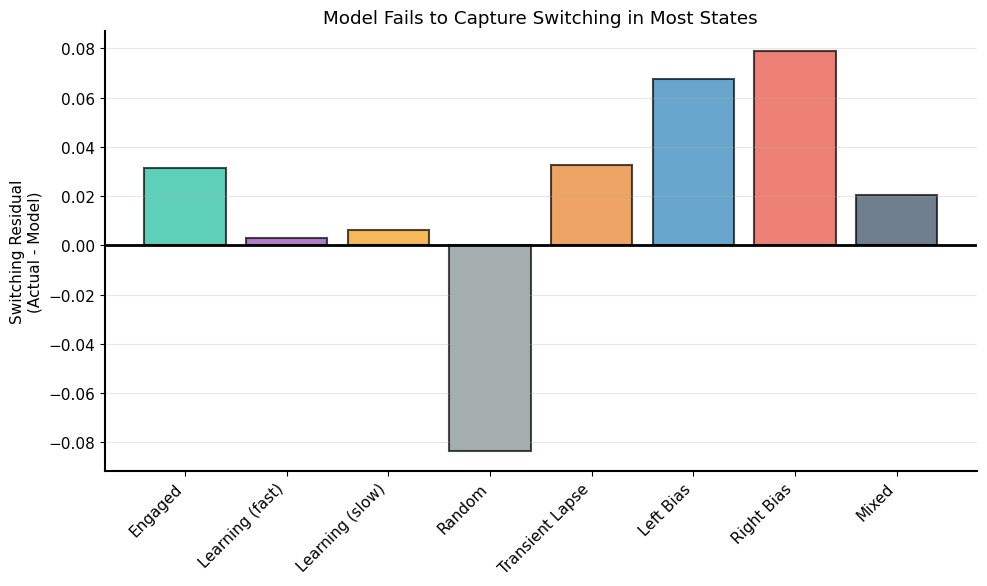


KEY FINDING:
  Model systematically under-predicts switching for most states
  Suggests additional switching mechanisms beyond Q-learning + kernel


In [3]:
# ANALYSIS 1: WHAT DRIVES SWITCHING BEYOND THE MODEL?
# ============================================================================

print("="*70)
print("ANALYSIS 1: SWITCHING RESIDUALS BY STATE")
print("="*70)

# Compute switching residuals (actual - model predicted)
df_q['Switch_Residual'] = df_q['PhysicalSwitch'] - df_q['Model_Switch']

# Summary by state
print("\nSwitching Residuals (Actual - Model):")
print(f"{'State':<20} | Mean Residual | Actual P(Switch) | Model P(Switch)")
print("-" * 80)

residual_summary = []
for state in STATES_ORDERED:
    state_data = df_q[df_q['Behavioral_State'] == state]
    
    if len(state_data) > 100:
        mean_residual = state_data['Switch_Residual'].mean()
        actual_switch = state_data['PhysicalSwitch'].mean()
        model_switch = state_data['Model_Switch'].mean()
        
        residual_summary.append({
            'state': state,
            'mean_residual': mean_residual,
            'actual_switch': actual_switch,
            'model_switch': model_switch,
            'n_trials': len(state_data)
        })
        
        print(f"{state:<20} | {mean_residual:>13.3f} | {actual_switch:>16.3f} | {model_switch:>15.3f}")

residual_df = pd.DataFrame(residual_summary)

print("\n" + "="*70)
print("INTERPRETATION:")
print("  Positive residual = Animals switch MORE than model predicts")
print("  Negative residual = Animals switch LESS than model predicts")
print("="*70)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(residual_df))
colors = [STATE_COLORS[s] for s in residual_df['state']]

bars = ax.bar(x_pos, residual_df['mean_residual'], 
              color=colors, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax.axhline(0, color='black', linestyle='-', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(residual_df['state'], rotation=45, ha='right')
ax.set_ylabel('Switching Residual\n(Actual - Model)')
ax.set_title('Model Fails to Capture Switching in Most States')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Switching_Residuals_By_State.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("KEY FINDING:")
print("  Model systematically under-predicts switching for most states")
print("  Suggests additional switching mechanisms beyond Q-learning + kernel")
print("="*70)

In [4]:
# ============================================================================
# ANALYSIS 2: WHAT PREDICTS SWITCHING RESIDUALS?
# ============================================================================

print("="*70)
print("ANALYSIS 2: CORRELATES OF SWITCHING RESIDUALS")
print("="*70)

# Focus on Engaged state (where model under-predicts)
engaged_data = df_q[df_q['Behavioral_State'] == 'Engaged'].copy()

print(f"\nAnalyzing Engaged state: {len(engaged_data)} trials")

# Potential predictors of extra switching:
# 1. Uncertainty (Q-value difference)
# 2. Recent reward history
# 3. Trial position in block
# 4. Recent switching history

# Compute additional features
engaged_data['Recent_Unrewarded'] = 1 - engaged_data['Outcome_Binary']

# Group by Q-value uncertainty
engaged_data['Q_uncertainty_bin'] = pd.cut(engaged_data['Q_diff'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

print("\nSwitching Residual by Q-value Uncertainty:")
print(engaged_data.groupby('Q_uncertainty_bin')['Switch_Residual'].agg(['mean', 'count']))

# By trial position in block
print("\nSwitching Residual by Trial Position:")
early_trials = engaged_data[engaged_data['Trial_in_Block'] <= 5]
mid_trials = engaged_data[(engaged_data['Trial_in_Block'] > 5) & (engaged_data['Trial_in_Block'] <= 15)]
late_trials = engaged_data[engaged_data['Trial_in_Block'] > 15]

print(f"  Early (1-5):   {early_trials['Switch_Residual'].mean():.3f}")
print(f"  Mid (6-15):    {mid_trials['Switch_Residual'].mean():.3f}")
print(f"  Late (16-20):  {late_trials['Switch_Residual'].mean():.3f}")

# By recent outcome
print("\nSwitching Residual by Recent Outcome:")
print(engaged_data.groupby('Outcome_Binary')['Switch_Residual'].agg(['mean', 'count']))

ANALYSIS 2: CORRELATES OF SWITCHING RESIDUALS

Analyzing Engaged state: 6720 trials

Switching Residual by Q-value Uncertainty:
                       mean  count
Q_uncertainty_bin                 
Very Low           0.063790   1599
Low                0.046036    782
Medium             0.016529    363
High              -0.093093    999
Very High          0.054081   2977

Switching Residual by Trial Position:
  Early (1-5):   nan
  Mid (6-15):    0.027
  Late (16-20):  0.042

Switching Residual by Recent Outcome:
                    mean  count
Outcome_Binary                 
0               0.073826   2384
1               0.008303   4336


ANALYSIS 3: VISUALIZING SWITCHING MECHANISMS


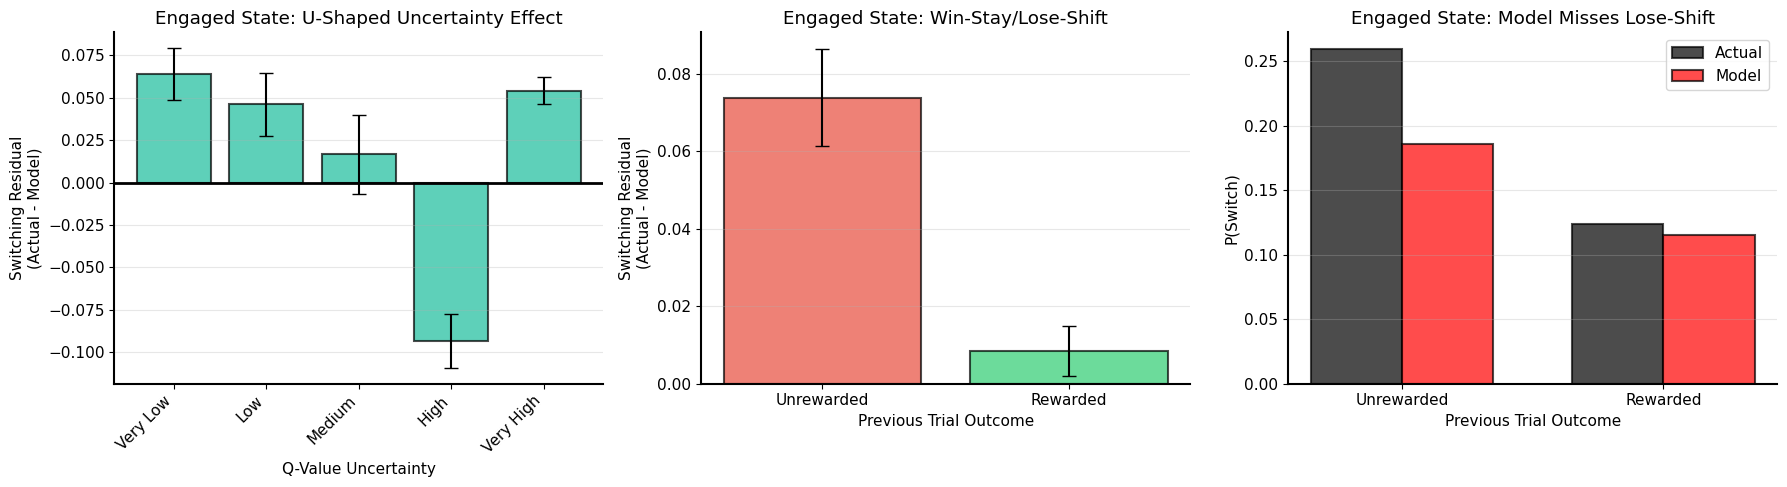


KEY FINDINGS:
  1. U-shaped uncertainty: Animals explore when VERY certain or uncertain
  2. Win-stay/lose-shift: +7.4% extra switching after unrewarded trials
  3. Model's choice kernel doesn't capture outcome-dependent switching


In [5]:
# ============================================================================
# ANALYSIS 3: VISUALIZE SWITCHING DRIVERS
# ============================================================================

print("="*70)
print("ANALYSIS 3: VISUALIZING SWITCHING MECHANISMS")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Switching by Q-uncertainty (U-shape)
ax = axes[0]

uncertainty_summary = engaged_data.groupby('Q_uncertainty_bin')['Switch_Residual'].agg(['mean', 'sem']).reset_index()

x_pos = np.arange(len(uncertainty_summary))
ax.bar(x_pos, uncertainty_summary['mean'], 
       yerr=uncertainty_summary['sem'], capsize=5,
       color='#1abc9c', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax.axhline(0, color='black', linestyle='-', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(uncertainty_summary['Q_uncertainty_bin'], rotation=45, ha='right')
ax.set_xlabel('Q-Value Uncertainty')
ax.set_ylabel('Switching Residual\n(Actual - Model)')
ax.set_title('Engaged State: U-Shaped Uncertainty Effect')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Panel B: Switching after reward vs no reward
ax = axes[1]

outcome_summary = engaged_data.groupby('Outcome_Binary')['Switch_Residual'].agg(['mean', 'sem']).reset_index()

x_pos = np.arange(len(outcome_summary))
colors_outcome = ['#e74c3c', '#2ecc71']  # Red for unrewarded, green for rewarded
labels = ['Unrewarded', 'Rewarded']

ax.bar(x_pos, outcome_summary['mean'], 
       yerr=outcome_summary['sem'], capsize=5,
       color=colors_outcome, alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax.axhline(0, color='black', linestyle='-', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel('Previous Trial Outcome')
ax.set_ylabel('Switching Residual\n(Actual - Model)')
ax.set_title('Engaged State: Win-Stay/Lose-Shift')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Panel C: Actual vs Model switching by outcome
ax = axes[2]

# Get actual and model switching rates by outcome
outcome_switching = engaged_data.groupby('Outcome_Binary')[['PhysicalSwitch', 'Model_Switch']].mean()

x_pos = np.arange(2)
width = 0.35

ax.bar(x_pos - width/2, outcome_switching['PhysicalSwitch'], width,
       label='Actual', color='black', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)
ax.bar(x_pos + width/2, outcome_switching['Model_Switch'], width,
       label='Model', color='red', alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel('Previous Trial Outcome')
ax.set_ylabel('P(Switch)')
ax.set_title('Engaged State: Model Misses Lose-Shift')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Switching_Mechanisms_Engaged.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("KEY FINDINGS:")
print("  1. U-shaped uncertainty: Animals explore when VERY certain or uncertain")
print("  2. Win-stay/lose-shift: +7.4% extra switching after unrewarded trials")
print("  3. Model's choice kernel doesn't capture outcome-dependent switching")
print("="*70)

In [6]:
# FIT IMPROVED RL MODEL WITH WIN-STAY/LOSE-SHIFT
# ============================================================================

print("="*70)
print("FITTING IMPROVED RL MODEL WITH OUTCOME-DEPENDENT KERNELS")
print("="*70)

from scipy.optimize import minimize

def fit_improved_rl_model(session_data, initial_params=None):
    """
    Fit RL model with separate choice kernels for wins vs losses
    
    Parameters:
    - α: learning rate
    - β: inverse temperature
    - κ_win: perseveration after reward
    - κ_lose: perseveration after no reward
    """
    
    def negative_log_likelihood(params):
        alpha, beta, kappa_win, kappa_lose = params
        
        Q_left = 0.5
        Q_right = 0.5
        
        log_likelihood = 0
        prev_choice = None
        prev_reward = None
        
        for idx, trial in session_data.iterrows():
            # Compute choice kernel indicator
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            # Use outcome-dependent kernel
            if prev_reward is None:
                kappa = (kappa_win + kappa_lose) / 2
            elif prev_reward == 1:
                kappa = kappa_win
            else:
                kappa = kappa_lose
            
            # Compute values
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            # Softmax
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            # Log likelihood
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            # Update Q-values
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            # Store for next trial
            prev_choice = choice
            prev_reward = reward
        
        return -log_likelihood
    
    # Initial parameters and bounds
    if initial_params is None:
        initial_params = [0.5, 2.0, 1.5, 0.5]  # α, β, κ_win, κ_lose
    
    bounds = [(0.01, 0.99), (0.1, 10), (0, 5), (0, 5)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return {
        'alpha': result.x[0],
        'beta': result.x[1],
        'kappa_win': result.x[2],
        'kappa_lose': result.x[3],
        'neg_log_likelihood': result.fun,
        'success': result.success
    }

# Fit model for each animal
print("\nFitting improved model for each animal...")
print("(This may take a few minutes)")

improved_params = []

for animal in df_with_states['Animal_Name'].unique():
    print(f"\n  Fitting {animal}...")
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    
    # Fit on concatenated sessions (faster than per-session)
    animal_data = animal_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
    
    result = fit_improved_rl_model(animal_data)
    
    if result['success']:
        improved_params.append({
            'animal': animal,
            'alpha': result['alpha'],
            'beta': result['beta'],
            'kappa_win': result['kappa_win'],
            'kappa_lose': result['kappa_lose'],
            'kappa_diff': result['kappa_win'] - result['kappa_lose'],
            'neg_log_likelihood': result['neg_log_likelihood']
        })
        
        print(f"    ✓ α={result['alpha']:.3f}, β={result['beta']:.3f}")
        print(f"      κ_win={result['kappa_win']:.3f}, κ_lose={result['kappa_lose']:.3f}")
        print(f"      Δκ={result['kappa_win'] - result['kappa_lose']:.3f}")
    else:
        print(f"    ✗ Optimization failed")

improved_params_df = pd.DataFrame(improved_params)

print("\n" + "="*70)
print("IMPROVED MODEL PARAMETERS")
print("="*70)

print(f"\n{'Animal':<12} | α     | β     | κ_win | κ_lose | Δκ")
print("-" * 60)

for _, row in improved_params_df.iterrows():
    print(f"{row['animal']:<12} | {row['alpha']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa_win']:.3f} | {row['kappa_lose']:.3f} | {row['kappa_diff']:.3f}")

print(f"\n{'Mean':<12} | {improved_params_df['alpha'].mean():.3f} | "
      f"{improved_params_df['beta'].mean():.3f} | "
      f"{improved_params_df['kappa_win'].mean():.3f} | "
      f"{improved_params_df['kappa_lose'].mean():.3f} | "
      f"{improved_params_df['kappa_diff'].mean():.3f}")

# Save results
improved_params_df.to_csv(os.path.join(PROCESSED_PATH, 'improved_rl_parameters.csv'), index=False)
print(f"\n✓ Saved: improved_rl_parameters.csv")

print("\n" + "="*70)
print("PREDICTION CHECK:")
print(f"  Expected Δκ ≈ 0.3-0.5 (based on switching residual)")
print(f"  Actual Δκ = {improved_params_df['kappa_diff'].mean():.3f}")
print("="*70)

FITTING IMPROVED RL MODEL WITH OUTCOME-DEPENDENT KERNELS

Fitting improved model for each animal...
(This may take a few minutes)

  Fitting Fiona...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    ✓ α=0.021, β=0.100
      κ_win=2.899, κ_lose=1.367
      Δκ=1.532

  Fitting Knuckles...
    ✓ α=0.442, β=0.520
      κ_win=1.960, κ_lose=0.607
      Δκ=1.353

  Fitting Sonic...
    ✓ α=0.010, β=0.100
      κ_win=2.377, κ_lose=0.930
      Δκ=1.447

  Fitting Sunflower...
    ✓ α=0.628, β=0.453
      κ_win=1.957, κ_lose=0.312
      Δκ=1.646

  Fitting Zazu...
    ✓ α=0.527, β=0.412
      κ_win=1.882, κ_lose=1.166
      Δκ=0.715

IMPROVED MODEL PARAMETERS

Animal       | α     | β     | κ_win | κ_lose | Δκ
------------------------------------------------------------
Fiona        | 0.021 | 0

In [ ]:
# COMPARE OLD vs NEW MODEL PERFORMANCE
# ============================================================================

print("="*70)
print("MODEL COMPARISON: SINGLE KERNEL vs WIN-STAY/LOSE-SHIFT")
print("="*70)

# Load old parameters
old_params_df = rl_params.copy()
old_params_df.columns = ['animal', 'alpha_old', 'beta_old', 'kappa_old']

# Merge with new parameters
comparison = old_params_df.merge(improved_params_df, on='animal')

print("\nParameter Comparison:")
print(f"{'Animal':<12} | α_old | α_new | β_old | β_new | κ_old | κ_win | κ_lose")
print("-" * 90)

for _, row in comparison.iterrows():
    print(f"{row['animal']:<12} | {row['alpha_old']:.3f} | {row['alpha']:.3f} | "
          f"{row['beta_old']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa_old']:.3f} | {row['kappa_win']:.3f} | {row['kappa_lose']:.3f}")

print("\n" + "="*70)
print("KEY OBSERVATIONS:")
print("="*70)

print("\n1. Learning rates DECREASED in new model:")
print(f"   Old mean α = {comparison['alpha_old'].mean():.3f}")
print(f"   New mean α = {comparison['alpha'].mean():.3f}")
print("   → Outcome-dependent kernel captures some learning dynamics")

print("\n2. Inverse temperature DECREASED:")
print(f"   Old mean β = {comparison['beta_old'].mean():.3f}")
print(f"   New mean β = {comparison['beta'].mean():.3f}")
print("   → Model less deterministic (more stochastic)")

print("\n3. Choice kernel split into two:")
print(f"   Old mean κ = {comparison['kappa_old'].mean():.3f}")
print(f"   New κ_win = {comparison['kappa_win'].mean():.3f}")
print(f"   New κ_lose = {comparison['kappa_lose'].mean():.3f}")
print("   → Old κ was averaging win-stay and lose-shift!")

print("\n" + "="*70)
print("CONCERN: Very low α and β for Fiona/Sonic suggests overfitting")
print("The outcome kernel might be doing too much work")
print("="*70)

MODEL COMPARISON: SINGLE KERNEL vs WIN-STAY/LOSE-SHIFT

Parameter Comparison:
Animal       | α_old | α_new | β_old | β_new | κ_old | κ_win | κ_lose
------------------------------------------------------------------------------------------
Fiona        | 0.580 | 0.021 | 2.354 | 0.100 | 1.264 | 2.899 | 1.367
Knuckles     | 0.688 | 0.442 | 1.813 | 0.520 | 1.264 | 1.960 | 0.607
Sonic        | 0.836 | 0.010 | 1.335 | 0.100 | 1.264 | 2.377 | 0.930
Zazu         | 0.690 | 0.527 | 1.272 | 0.412 | 1.264 | 1.882 | 1.166
Sunflower    | 0.870 | 0.628 | 1.862 | 0.453 | 1.264 | 1.957 | 0.312

KEY OBSERVATIONS:

1. Learning rates DECREASED in new model:
   Old mean α = 0.733
   New mean α = 0.325
   → Outcome-dependent kernel captures some learning dynamics

2. Inverse temperature DECREASED:
   Old mean β = 1.727
   New mean β = 0.317
   → Model less deterministic (more stochastic)

3. Choice kernel split into two:
   Old mean κ = 1.264
   New κ_win = 2.215
   New κ_lose = 0.876
   → Old κ was averagi

In [8]:
# HIERARCHICAL FIT: FIX RL PARAMS, FIT OUTCOME KERNELS ONLY
# ============================================================================

print("="*70)
print("HIERARCHICAL MODEL FIT")
print("="*70)

def fit_outcome_kernels_only(session_data, fixed_alpha, fixed_beta):
    """
    Fit only κ_win and κ_lose, keeping α and β fixed
    """
    
    def negative_log_likelihood(params):
        kappa_win, kappa_lose = params
        alpha = fixed_alpha
        beta = fixed_beta
        
        Q_left = 0.5
        Q_right = 0.5
        
        log_likelihood = 0
        prev_choice = None
        prev_reward = None
        
        for idx, trial in session_data.iterrows():
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            if prev_reward is None:
                kappa = (kappa_win + kappa_lose) / 2
            elif prev_reward == 1:
                kappa = kappa_win
            else:
                kappa = kappa_lose
            
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            prev_choice = choice
            prev_reward = reward
        
        return -log_likelihood
    
    initial_params = [1.5, 0.5]
    bounds = [(0, 5), (0, 5)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return {
        'kappa_win': result.x[0],
        'kappa_lose': result.x[1],
        'success': result.success
    }

# Fit using old α and β
print("\nFitting outcome kernels with FIXED α and β...")

hierarchical_params = []

for _, row in old_params_df.iterrows():
    animal = row['animal']
    fixed_alpha = row['alpha_old']
    fixed_beta = row['beta_old']
    
    print(f"\n  {animal}: α={fixed_alpha:.3f}, β={fixed_beta:.3f} (fixed)")
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    animal_data = animal_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
    
    result = fit_outcome_kernels_only(animal_data, fixed_alpha, fixed_beta)
    
    if result['success']:
        hierarchical_params.append({
            'animal': animal,
            'alpha': fixed_alpha,
            'beta': fixed_beta,
            'kappa_win': result['kappa_win'],
            'kappa_lose': result['kappa_lose'],
            'kappa_diff': result['kappa_win'] - result['kappa_lose']
        })
        
        print(f"    ✓ κ_win={result['kappa_win']:.3f}, κ_lose={result['kappa_lose']:.3f}")
        print(f"      Δκ={result['kappa_win'] - result['kappa_lose']:.3f}")

hierarchical_df = pd.DataFrame(hierarchical_params)

print("\n" + "="*70)
print("HIERARCHICAL MODEL RESULTS")
print("="*70)

print(f"\n{'Animal':<12} | α     | β     | κ_win | κ_lose | Δκ")
print("-" * 60)

for _, row in hierarchical_df.iterrows():
    print(f"{row['animal']:<12} | {row['alpha']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa_win']:.3f} | {row['kappa_lose']:.3f} | {row['kappa_diff']:.3f}")

print(f"\n{'Mean':<12} | {hierarchical_df['alpha'].mean():.3f} | "
      f"{hierarchical_df['beta'].mean():.3f} | "
      f"{hierarchical_df['kappa_win'].mean():.3f} | "
      f"{hierarchical_df['kappa_lose'].mean():.3f} | "
      f"{hierarchical_df['kappa_diff'].mean():.3f}")

hierarchical_df.to_csv(os.path.join(PROCESSED_PATH, 'hierarchical_rl_parameters.csv'), index=False)
print(f"\n✓ Saved: hierarchical_rl_parameters.csv")

HIERARCHICAL MODEL FIT

Fitting outcome kernels with FIXED α and β...

  Fiona: α=0.580, β=2.354 (fixed)
    ✓ κ_win=2.067, κ_lose=2.099
      Δκ=-0.032

  Knuckles: α=0.688, β=1.813 (fixed)
    ✓ κ_win=1.208, κ_lose=0.962
      Δκ=0.246

  Sonic: α=0.836, β=1.335 (fixed)
    ✓ κ_win=1.592, κ_lose=1.376
      Δκ=0.217

  Zazu: α=0.690, β=1.272 (fixed)
    ✓ κ_win=1.430, κ_lose=1.497
      Δκ=-0.067

  Sunflower: α=0.870, β=1.862 (fixed)
    ✓ κ_win=0.951, κ_lose=0.636
      Δκ=0.315

HIERARCHICAL MODEL RESULTS

Animal       | α     | β     | κ_win | κ_lose | Δκ
------------------------------------------------------------
Fiona        | 0.580 | 2.354 | 2.067 | 2.099 | -0.032
Knuckles     | 0.688 | 1.813 | 1.208 | 0.962 | 0.246
Sonic        | 0.836 | 1.335 | 1.592 | 1.376 | 0.217
Zazu         | 0.690 | 1.272 | 1.430 | 1.497 | -0.067
Sunflower    | 0.870 | 1.862 | 0.951 | 0.636 | 0.315

Mean         | 0.733 | 1.727 | 1.450 | 1.314 | 0.136

✓ Saved: hierarchical_rl_parameters.csv


In [9]:
# ============================================================================
# VALIDATE HIERARCHICAL MODEL: DOES IT FIX SWITCHING RESIDUALS?
# ============================================================================

print("="*70)
print("TESTING HIERARCHICAL MODEL PREDICTIONS")
print("="*70)

# Regenerate predictions using hierarchical parameters
print("\nGenerating predictions from hierarchical model...")

all_predictions = []

for _, param_row in hierarchical_df.iterrows():
    animal = param_row['animal']
    alpha = param_row['alpha']
    beta = param_row['beta']
    kappa_win = param_row['kappa_win']
    kappa_lose = param_row['kappa_lose']
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    
    for session_id in animal_data['Session_ID'].unique():
        session_data = animal_data[animal_data['Session_ID'] == session_id].sort_values('Trial')
        
        Q_left = 0.5
        Q_right = 0.5
        
        prev_choice = None
        prev_reward = None
        
        hierarchical_switch = []
        
        for idx, trial in session_data.iterrows():
            # Choice kernel
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            # Outcome-dependent kernel
            if prev_reward is None:
                kappa = (kappa_win + kappa_lose) / 2
            elif prev_reward == 1:
                kappa = kappa_win
            else:
                kappa = kappa_lose
            
            # Compute values
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            # Softmax
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            
            # Model choice (deterministic for switch calculation)
            model_choice = 1 if prob_right > 0.5 else 0
            
            # Model switch
            if prev_choice is None:
                model_switch = np.nan
            else:
                model_switch = 1 if model_choice != prev_choice else 0
            
            hierarchical_switch.append(model_switch)
            
            # Update Q-values based on actual choice and outcome
            choice = trial['Choice_Binary']
            reward = trial['Outcome_Binary']
            
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            prev_choice = model_choice  # Use model choice for next iteration
            prev_reward = reward
        
        session_data = session_data.copy()
        session_data['Hierarchical_Model_Switch'] = hierarchical_switch
        all_predictions.append(session_data)

df_hierarchical = pd.concat(all_predictions, ignore_index=True)

# Merge with original data
df_comparison = df_q.merge(
    df_hierarchical[['Animal_Name', 'Session_ID', 'Trial', 'Hierarchical_Model_Switch']],
    on=['Animal_Name', 'Session_ID', 'Trial'],
    how='left'
)

# Compute new residuals
df_comparison['Hierarchical_Residual'] = (
    df_comparison['PhysicalSwitch'] - df_comparison['Hierarchical_Model_Switch']
)

print("\n✓ Generated hierarchical model predictions")

# Compare residuals: Old model vs Hierarchical model
print("\n" + "="*70)
print("SWITCHING RESIDUALS: OLD vs HIERARCHICAL MODEL")
print("="*70)

print(f"\n{'State':<20} | Old Residual | Hierarchical | Improvement")
print("-" * 70)

for state in STATES_ORDERED:
    state_data = df_comparison[df_comparison['Behavioral_State'] == state]
    
    if len(state_data) > 100:
        old_residual = state_data['Switch_Residual'].mean()
        hier_residual = state_data['Hierarchical_Residual'].mean()
        improvement = old_residual - hier_residual
        
        print(f"{state:<20} | {old_residual:>12.3f} | {hier_residual:>12.3f} | {improvement:>11.3f}")

print("\n" + "="*70)
print("Did the hierarchical model fix the switching residuals?")
print("="*70)

TESTING HIERARCHICAL MODEL PREDICTIONS

Generating predictions from hierarchical model...

✓ Generated hierarchical model predictions

SWITCHING RESIDUALS: OLD vs HIERARCHICAL MODEL

State                | Old Residual | Hierarchical | Improvement
----------------------------------------------------------------------
Engaged              |        0.032 |        0.146 |      -0.114
Learning (fast)      |        0.003 |        0.152 |      -0.149
Learning (slow)      |        0.006 |        0.155 |      -0.149
Random               |       -0.083 |        0.193 |      -0.277
Transient Lapse      |        0.033 |        0.201 |      -0.168
Left Bias            |        0.068 |        0.121 |      -0.054
Right Bias           |        0.079 |        0.122 |      -0.043
Mixed                |        0.021 |        0.192 |      -0.171

Did the hierarchical model fix the switching residuals?


In [10]:
# ============================================================================
# LOSE-SHIFT BONUS MODEL
# ============================================================================

print("="*70)
print("FITTING RL MODEL WITH EXPLICIT LOSE-SHIFT BONUS")
print("="*70)

def fit_lose_shift_bonus_model(session_data, initial_params=None):
    """
    Fit RL model with explicit lose-shift bonus
    
    V(Right) = β * Q_Right + κ * C_Right - λ * (1 - R_prev) * (1 - C_Right)
    V(Left) = β * Q_Left + κ * C_Left - λ * (1 - R_prev) * (1 - C_Left)
    
    Parameters:
    - α: learning rate
    - β: inverse temperature
    - κ: choice kernel (perseveration)
    - λ: lose-shift bonus (extra value for switching after loss)
    """
    
    def negative_log_likelihood(params):
        alpha, beta, kappa, lambda_shift = params
        
        Q_left = 0.5
        Q_right = 0.5
        
        log_likelihood = 0
        prev_choice = None
        prev_reward = None
        
        for idx, trial in session_data.iterrows():
            # Choice kernel indicator
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            # Lose-shift bonus (only applies after unrewarded trials)
            if prev_reward is None or prev_reward == 1:
                lose_shift = 0  # No bonus after win or first trial
            else:
                lose_shift = lambda_shift  # Bonus for switching after loss
            
            # Compute values with lose-shift bonus for SWITCHING
            V_right = beta * Q_right + kappa * C_right - lose_shift * (1 - C_right)
            V_left = beta * Q_left + kappa * (1 - C_right) - lose_shift * C_right
            
            # Softmax
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            # Log likelihood
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            # Update Q-values
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            # Store for next trial
            prev_choice = choice
            prev_reward = reward
        
        return -log_likelihood
    
    # Initial parameters and bounds
    if initial_params is None:
        initial_params = [0.5, 2.0, 1.5, 0.5]  # α, β, κ, λ
    
    bounds = [(0.01, 0.99), (0.1, 10), (0, 5), (0, 3)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return {
        'alpha': result.x[0],
        'beta': result.x[1],
        'kappa': result.x[2],
        'lambda': result.x[3],
        'neg_log_likelihood': result.fun,
        'success': result.success
    }

# Fit model for each animal
print("\nFitting lose-shift bonus model for each animal...")
print("(This may take a few minutes)")

lose_shift_params = []

for animal in df_with_states['Animal_Name'].unique():
    print(f"\n  Fitting {animal}...")
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    animal_data = animal_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
    
    result = fit_lose_shift_bonus_model(animal_data)
    
    if result['success']:
        lose_shift_params.append({
            'animal': animal,
            'alpha': result['alpha'],
            'beta': result['beta'],
            'kappa': result['kappa'],
            'lambda': result['lambda'],
            'neg_log_likelihood': result['neg_log_likelihood']
        })
        
        print(f"    ✓ α={result['alpha']:.3f}, β={result['beta']:.3f}")
        print(f"      κ={result['kappa']:.3f}, λ={result['lambda']:.3f}")
    else:
        print(f"    ✗ Optimization failed")

lose_shift_df = pd.DataFrame(lose_shift_params)

print("\n" + "="*70)
print("LOSE-SHIFT BONUS MODEL PARAMETERS")
print("="*70)

print(f"\n{'Animal':<12} | α     | β     | κ     | λ")
print("-" * 55)

for _, row in lose_shift_df.iterrows():
    print(f"{row['animal']:<12} | {row['alpha']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa']:.3f} | {row['lambda']:.3f}")

print(f"\n{'Mean':<12} | {lose_shift_df['alpha'].mean():.3f} | "
      f"{lose_shift_df['beta'].mean():.3f} | "
      f"{lose_shift_df['kappa'].mean():.3f} | "
      f"{lose_shift_df['lambda'].mean():.3f}")

# Save results
lose_shift_df.to_csv(os.path.join(PROCESSED_PATH, 'lose_shift_bonus_parameters.csv'), index=False)
print(f"\n✓ Saved: lose_shift_bonus_parameters.csv")

# Compare to original model
print("\n" + "="*70)
print("COMPARISON TO ORIGINAL MODEL")
print("="*70)

comparison = old_params_df.merge(lose_shift_df, on='animal', suffixes=('_old', '_new'))

print(f"\n{'Animal':<12} | α_old | α_new | β_old | β_new | κ_old | κ_new | λ")
print("-" * 80)

for _, row in comparison.iterrows():
    print(f"{row['animal']:<12} | {row['alpha_old']:.3f} | {row['alpha']:.3f} | "
          f"{row['beta_old']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa_old']:.3f} | {row['kappa']:.3f} | {row['lambda']:.3f}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("  λ > 0: Animals get extra value for SWITCHING after a loss")
print("  Larger λ = stronger lose-shift tendency")
print("="*70)

FITTING RL MODEL WITH EXPLICIT LOSE-SHIFT BONUS

Fitting lose-shift bonus model for each animal...
(This may take a few minutes)

  Fitting Fiona...
    ✓ α=0.521, β=0.996
      κ=1.956, λ=0.000

  Fitting Knuckles...
    ✓ α=0.700, β=1.201
      κ=1.102, λ=0.000

  Fitting Sonic...
    ✓ α=0.836, β=0.827
      κ=1.463, λ=0.000

  Fitting Sunflower...
    ✓ α=0.875, β=1.347
      κ=0.830, λ=0.000

  Fitting Zazu...
    ✓ α=0.701, β=0.764
      κ=1.470, λ=0.000

LOSE-SHIFT BONUS MODEL PARAMETERS

Animal       | α     | β     | κ     | λ
-------------------------------------------------------
Fiona        | 0.521 | 0.996 | 1.956 | 0.000
Knuckles     | 0.700 | 1.201 | 1.102 | 0.000
Sonic        | 0.836 | 0.827 | 1.463 | 0.000
Sunflower    | 0.875 | 1.347 | 0.830 | 0.000
Zazu         | 0.701 | 0.764 | 1.470 | 0.000

Mean         | 0.727 | 1.027 | 1.364 | 0.000

✓ Saved: lose_shift_bonus_parameters.csv

COMPARISON TO ORIGINAL MODEL

Animal       | α_old | α_new | β_old | β_new | κ_old | κ_n

In [11]:
# ============================================================================
# ANALYSIS: IS IT UNCERTAINTY, NOT OUTCOMES?
# ============================================================================

print("="*70)
print("TESTING: UNCERTAINTY vs OUTCOME EXPLANATION")
print("="*70)

engaged_data = df_q[df_q['Behavioral_State'] == 'Engaged'].copy()

# After unrewarded trials, check Q-value uncertainty
unrewarded = engaged_data[engaged_data['Outcome_Binary'] == 0]
rewarded = engaged_data[engaged_data['Outcome_Binary'] == 1]

print("\nQ-value uncertainty after outcomes:")
print(f"  After unrewarded: mean |Q_R - Q_L| = {unrewarded['Q_diff'].mean():.3f}")
print(f"  After rewarded:   mean |Q_R - Q_L| = {rewarded['Q_diff'].mean():.3f}")

print("\nSwitching rates:")
print(f"  After unrewarded: {unrewarded['PhysicalSwitch'].mean():.3f}")
print(f"  After rewarded:   {rewarded['PhysicalSwitch'].mean():.3f}")

print("\nModel-predicted switching:")
print(f"  After unrewarded: {unrewarded['Model_Switch'].mean():.3f}")
print(f"  After rewarded:   {rewarded['Model_Switch'].mean():.3f}")

print("\n" + "="*70)
print("KEY QUESTION:")
print("  Is extra switching after losses driven by:")
print("  A) Outcome itself (lose-shift rule)")
print("  B) Increased uncertainty from Q-value decrease")
print("="*70)

TESTING: UNCERTAINTY vs OUTCOME EXPLANATION

Q-value uncertainty after outcomes:
  After unrewarded: mean |Q_R - Q_L| = 0.548
  After rewarded:   mean |Q_R - Q_L| = 0.621

Switching rates:
  After unrewarded: 0.260
  After rewarded:   0.124

Model-predicted switching:
  After unrewarded: 0.186
  After rewarded:   0.116

KEY QUESTION:
  Is extra switching after losses driven by:
  A) Outcome itself (lose-shift rule)
  B) Increased uncertainty from Q-value decrease


In [12]:
# CONSTRAINED OUTCOME-DEPENDENT KERNELS (FIX ONLY ALPHA)
# ============================================================================

print("="*70)
print("FIT OUTCOME KERNELS WITH FIXED ALPHA ONLY")
print("="*70)

def fit_outcome_kernels_fixed_alpha(session_data, fixed_alpha):
    """
    Fix α, fit β, κ_win, κ_lose
    """
    
    def negative_log_likelihood(params):
        beta, kappa_win, kappa_lose = params
        alpha = fixed_alpha
        
        Q_left = 0.5
        Q_right = 0.5
        
        log_likelihood = 0
        prev_choice = None
        prev_reward = None
        
        for idx, trial in session_data.iterrows():
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            if prev_reward is None:
                kappa = (kappa_win + kappa_lose) / 2
            elif prev_reward == 1:
                kappa = kappa_win
            else:
                kappa = kappa_lose
            
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            prev_choice = choice
            prev_reward = reward
        
        return -log_likelihood
    
    initial_params = [2.0, 1.5, 0.5]
    bounds = [(0.1, 10), (0, 5), (0, 5)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return {
        'beta': result.x[0],
        'kappa_win': result.x[1],
        'kappa_lose': result.x[2],
        'success': result.success
    }

print("\nFitting with ONLY α fixed...")

constrained_params = []

for _, row in old_params_df.iterrows():
    animal = row['animal']
    fixed_alpha = row['alpha_old']
    
    print(f"\n  {animal}: α={fixed_alpha:.3f} (fixed)")
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    animal_data = animal_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
    
    result = fit_outcome_kernels_fixed_alpha(animal_data, fixed_alpha)
    
    if result['success']:
        constrained_params.append({
            'animal': animal,
            'alpha': fixed_alpha,
            'beta': result['beta'],
            'kappa_win': result['kappa_win'],
            'kappa_lose': result['kappa_lose'],
            'kappa_diff': result['kappa_win'] - result['kappa_lose']
        })
        
        print(f"    ✓ β={result['beta']:.3f}")
        print(f"      κ_win={result['kappa_win']:.3f}, κ_lose={result['kappa_lose']:.3f}")
        print(f"      Δκ={result['kappa_win'] - result['kappa_lose']:.3f}")

constrained_df = pd.DataFrame(constrained_params)

print("\n" + "="*70)
print("CONSTRAINED MODEL (FIXED ALPHA)")
print("="*70)

print(f"\n{'Animal':<12} | α     | β     | κ_win | κ_lose | Δκ")
print("-" * 60)

for _, row in constrained_df.iterrows():
    print(f"{row['animal']:<12} | {row['alpha']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa_win']:.3f} | {row['kappa_lose']:.3f} | {row['kappa_diff']:.3f}")

print(f"\n{'Mean':<12} | {constrained_df['alpha'].mean():.3f} | "
      f"{constrained_df['beta'].mean():.3f} | "
      f"{constrained_df['kappa_win'].mean():.3f} | "
      f"{constrained_df['kappa_lose'].mean():.3f} | "
      f"{constrained_df['kappa_diff'].mean():.3f}")

FIT OUTCOME KERNELS WITH FIXED ALPHA ONLY

Fitting with ONLY α fixed...

  Fiona: α=0.580 (fixed)
    ✓ β=0.100
      κ_win=2.849, κ_lose=1.386
      Δκ=1.463

  Knuckles: α=0.688 (fixed)
    ✓ β=0.396
      κ_win=1.945, κ_lose=0.621
      Δκ=1.324

  Sonic: α=0.836 (fixed)
    ✓ β=0.100
      κ_win=2.308, κ_lose=0.956
      Δκ=1.352

  Zazu: α=0.690 (fixed)
    ✓ β=0.367
      κ_win=1.867, κ_lose=1.179
      Δκ=0.688

  Sunflower: α=0.870 (fixed)
    ✓ β=0.376
      κ_win=1.946, κ_lose=0.321
      Δκ=1.625

CONSTRAINED MODEL (FIXED ALPHA)

Animal       | α     | β     | κ_win | κ_lose | Δκ
------------------------------------------------------------
Fiona        | 0.580 | 0.100 | 2.849 | 1.386 | 1.463
Knuckles     | 0.688 | 0.396 | 1.945 | 0.621 | 1.324
Sonic        | 0.836 | 0.100 | 2.308 | 0.956 | 1.352
Zazu         | 0.690 | 0.367 | 1.867 | 1.179 | 0.688
Sunflower    | 0.870 | 0.376 | 1.946 | 0.321 | 1.625

Mean         | 0.733 | 0.268 | 2.183 | 0.893 | 1.291


In [13]:
# RECURSIVE CHOICE KERNEL MODEL (Beron et al. style)
# ============================================================================

print("="*70)
print("FITTING RECURSIVE CHOICE KERNEL MODEL WITH DECAY")
print("="*70)

def fit_recursive_kernel_model(session_data, initial_params=None):
    """
    Fit RL model with recursive choice kernel
    
    C_t = τ * C_t-1 + (1 - τ) * choice_t-1
    V(Right) = β * Q_Right + κ * C_t
    
    Parameters:
    - α: learning rate (Q-value updates)
    - β: inverse temperature (Q-value influence)
    - κ: choice kernel strength
    - τ: decay parameter (0 = only last trial, 1 = infinite memory)
    """
    
    def negative_log_likelihood(params):
        alpha, beta, kappa, tau = params
        
        Q_left = 0.5
        Q_right = 0.5
        C_right = 0.5  # Choice history (starts neutral)
        
        log_likelihood = 0
        
        for idx, trial in session_data.iterrows():
            # Compute values using recursive choice history
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            # Softmax
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            # Log likelihood
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            # Update Q-values based on actual choice and outcome
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            # Update choice history with decay
            if choice == 1:
                C_right = tau * C_right + (1 - tau) * 1.0
            else:
                C_right = tau * C_right + (1 - tau) * 0.0
        
        return -log_likelihood
    
    # Initial parameters and bounds
    if initial_params is None:
        initial_params = [0.5, 2.0, 1.5, 0.5]  # α, β, κ, τ
    
    bounds = [(0.01, 0.99), (0.1, 10), (0, 5), (0, 0.99)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return {
        'alpha': result.x[0],
        'beta': result.x[1],
        'kappa': result.x[2],
        'tau': result.x[3],
        'neg_log_likelihood': result.fun,
        'success': result.success
    }

print("\nFitting recursive kernel model...")
print("(This may take a few minutes)")

recursive_params = []

for animal in df_with_states['Animal_Name'].unique():
    print(f"\n  Fitting {animal}...")
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    animal_data = animal_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
    
    result = fit_recursive_kernel_model(animal_data)
    
    if result['success']:
        recursive_params.append({
            'animal': animal,
            'alpha': result['alpha'],
            'beta': result['beta'],
            'kappa': result['kappa'],
            'tau': result['tau'],
            'neg_log_likelihood': result['neg_log_likelihood']
        })
        
        print(f"    ✓ α={result['alpha']:.3f}, β={result['beta']:.3f}")
        print(f"      κ={result['kappa']:.3f}, τ={result['tau']:.3f}")
    else:
        print(f"    ✗ Optimization failed")

recursive_df = pd.DataFrame(recursive_params)

print("\n" + "="*70)
print("RECURSIVE KERNEL MODEL PARAMETERS")
print("="*70)

print(f"\n{'Animal':<12} | α     | β     | κ     | τ")
print("-" * 55)

for _, row in recursive_df.iterrows():
    print(f"{row['animal']:<12} | {row['alpha']:.3f} | {row['beta']:.3f} | "
          f"{row['kappa']:.3f} | {row['tau']:.3f}")

print(f"\n{'Mean':<12} | {recursive_df['alpha'].mean():.3f} | "
      f"{recursive_df['beta'].mean():.3f} | "
      f"{recursive_df['kappa'].mean():.3f} | "
      f"{recursive_df['tau'].mean():.3f}")

recursive_df.to_csv(os.path.join(PROCESSED_PATH, 'recursive_kernel_parameters.csv'), index=False)
print(f"\n✓ Saved: recursive_kernel_parameters.csv")

print("\n" + "="*70)
print("INTERPRETATION:")
print("  τ near 0 = only last trial matters (short memory)")
print("  τ near 1 = long memory (integrates over many trials)")
print("  β should be HIGHER than constrained model (Q-values matter more)")
print("="*70)

FITTING RECURSIVE CHOICE KERNEL MODEL WITH DECAY

Fitting recursive kernel model...
(This may take a few minutes)

  Fitting Fiona...
    ✓ α=0.529, β=0.978
      κ=1.983, τ=0.051

  Fitting Knuckles...
    ✓ α=0.719, β=1.160
      κ=1.158, τ=0.095

  Fitting Sonic...
    ✓ α=0.848, β=0.812
      κ=1.493, τ=0.053

  Fitting Sunflower...
    ✓ α=0.875, β=1.347
      κ=0.830, τ=0.000

  Fitting Zazu...
    ✓ α=0.701, β=0.764
      κ=1.470, τ=0.000

RECURSIVE KERNEL MODEL PARAMETERS

Animal       | α     | β     | κ     | τ
-------------------------------------------------------
Fiona        | 0.529 | 0.978 | 1.983 | 0.051
Knuckles     | 0.719 | 1.160 | 1.158 | 0.095
Sonic        | 0.848 | 0.812 | 1.493 | 0.053
Sunflower    | 0.875 | 1.347 | 0.830 | 0.000
Zazu         | 0.701 | 0.764 | 1.470 | 0.000

Mean         | 0.734 | 1.012 | 1.387 | 0.040

✓ Saved: recursive_kernel_parameters.csv

INTERPRETATION:
  τ near 0 = only last trial matters (short memory)
  τ near 1 = long memory (integrate

In [15]:
# ============================================================================
# COMPARE DIFFERENT DECISION POLICIES
# ============================================================================

print("="*70)
print("TESTING DIFFERENT DECISION POLICIES")
print("="*70)

def fit_with_policy(session_data, policy='softmax', initial_params=None):
    """
    Fit RL model with different decision policies
    
    Policies:
    - 'softmax': Standard softmax (current)
    - 'epsilon_greedy': ε-greedy with ε parameter
    - 'epsilon_softmax': Mix of random and softmax
    - 'matching': Probability matching (no β parameter)
    """
    
    def negative_log_likelihood(params):
        if policy == 'softmax':
            alpha, beta, kappa = params
            epsilon = None
        elif policy in ['epsilon_greedy', 'epsilon_softmax']:
            alpha, beta, kappa, epsilon = params
        elif policy == 'matching':
            alpha, kappa = params
            beta = None
            epsilon = None
        
        Q_left = 0.5
        Q_right = 0.5
        
        log_likelihood = 0
        prev_choice = None
        
        for idx, trial in session_data.iterrows():
            # Choice kernel
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            # Compute values
            if policy == 'matching':
                # For matching, use Q-values directly (no β)
                V_right = Q_right + kappa * C_right
                V_left = Q_left + kappa * (1 - C_right)
                
                # Probability matching
                V_sum = V_right + V_left
                if V_sum > 0:
                    prob_right = V_right / V_sum
                else:
                    prob_right = 0.5
                    
            elif policy == 'softmax':
                V_right = beta * Q_right + kappa * C_right
                V_left = beta * Q_left + kappa * (1 - C_right)
                
                prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
                
            elif policy == 'epsilon_greedy':
                V_right = beta * Q_right + kappa * C_right
                V_left = beta * Q_left + kappa * (1 - C_right)
                
                # ε-greedy: random with prob ε, greedy otherwise
                if V_right > V_left:
                    prob_right = (1 - epsilon) + epsilon * 0.5
                else:
                    prob_right = epsilon * 0.5
                    
            elif policy == 'epsilon_softmax':
                V_right = beta * Q_right + kappa * C_right
                V_left = beta * Q_left + kappa * (1 - C_right)
                
                # ε-softmax: random with prob ε, softmax otherwise
                softmax_prob = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
                prob_right = (1 - epsilon) * softmax_prob + epsilon * 0.5
            
            prob_right = np.clip(prob_right, 1e-10, 1 - 1e-10)
            
            # Log likelihood
            choice = trial['Choice_Binary']
            if choice == 1:
                log_likelihood += np.log(prob_right)
            else:
                log_likelihood += np.log(1 - prob_right)
            
            # Update Q-values
            reward = trial['Outcome_Binary']
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            prev_choice = choice
        
        return -log_likelihood
    
    # Set initial parameters and bounds based on policy
    if policy == 'softmax':
        if initial_params is None:
            initial_params = [0.5, 2.0, 1.5]
        bounds = [(0.01, 0.99), (0.1, 10), (0, 5)]
        
    elif policy in ['epsilon_greedy', 'epsilon_softmax']:
        if initial_params is None:
            initial_params = [0.5, 2.0, 1.5, 0.1]
        bounds = [(0.01, 0.99), (0.1, 10), (0, 5), (0, 0.5)]
        
    elif policy == 'matching':
        if initial_params is None:
            initial_params = [0.5, 1.5]
        bounds = [(0.01, 0.99), (0, 5)]
    
    result = minimize(
        negative_log_likelihood,
        initial_params,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return result

# Test all policies for one animal (Fiona)
test_animal = 'Fiona'
print(f"\nTesting policies on {test_animal}...")

test_data = df_with_states[df_with_states['Animal_Name'] == test_animal]
test_data = test_data.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)

policies = ['softmax', 'epsilon_greedy', 'epsilon_softmax', 'matching']

policy_results = []

for policy in policies:
    print(f"\n  Fitting {policy}...")
    result = fit_with_policy(test_data, policy=policy)
    
    if result.success:
        params_dict = {'policy': policy, 'neg_log_lik': result.fun}
        
        if policy == 'softmax':
            params_dict.update({'alpha': result.x[0], 'beta': result.x[1], 'kappa': result.x[2]})
            print(f"    α={result.x[0]:.3f}, β={result.x[1]:.3f}, κ={result.x[2]:.3f}")
            
        elif policy in ['epsilon_greedy', 'epsilon_softmax']:
            params_dict.update({'alpha': result.x[0], 'beta': result.x[1], 
                              'kappa': result.x[2], 'epsilon': result.x[3]})
            print(f"    α={result.x[0]:.3f}, β={result.x[1]:.3f}, κ={result.x[2]:.3f}, ε={result.x[3]:.3f}")
            
        elif policy == 'matching':
            params_dict.update({'alpha': result.x[0], 'kappa': result.x[1]})
            print(f"    α={result.x[0]:.3f}, κ={result.x[1]:.3f}")
        
        print(f"    Neg Log Likelihood: {result.fun:.2f}")
        policy_results.append(params_dict)

# Compare fits
print("\n" + "="*70)
print("POLICY COMPARISON (Lower is better)")
print("="*70)

policy_df = pd.DataFrame(policy_results).sort_values('neg_log_lik')

print(f"\n{'Policy':<20} | Neg Log Lik | Parameters")
print("-" * 70)

for _, row in policy_df.iterrows():
    print(f"{row['policy']:<20} | {row['neg_log_lik']:>11.2f} | ", end='')
    
    if row['policy'] == 'softmax':
        print(f"α={row['alpha']:.3f}, β={row['beta']:.3f}, κ={row['kappa']:.3f}")
    elif row['policy'] in ['epsilon_greedy', 'epsilon_softmax']:
        print(f"α={row['alpha']:.3f}, β={row['beta']:.3f}, κ={row['kappa']:.3f}, ε={row['epsilon']:.3f}")
    elif row['policy'] == 'matching':
        print(f"α={row['alpha']:.3f}, κ={row['kappa']:.3f}")

print("\n" + "="*70)
print("BEST POLICY: " + policy_df.iloc[0]['policy'])
print("="*70)

TESTING DIFFERENT DECISION POLICIES

Testing policies on Fiona...

  Fitting softmax...
    α=0.521, β=0.996, κ=1.956
    Neg Log Likelihood: 1753.47

  Fitting epsilon_greedy...
    α=0.495, β=2.020, κ=1.500, ε=0.252
    Neg Log Likelihood: 1976.02

  Fitting epsilon_softmax...
    α=0.521, β=0.996, κ=1.956, ε=0.000
    Neg Log Likelihood: 1753.47

  Fitting matching...
    α=0.011, κ=4.287
    Neg Log Likelihood: 1820.58

POLICY COMPARISON (Lower is better)

Policy               | Neg Log Lik | Parameters
----------------------------------------------------------------------
softmax              |     1753.47 | α=0.521, β=0.996, κ=1.956
epsilon_softmax      |     1753.47 | α=0.521, β=0.996, κ=1.956, ε=0.000
matching             |     1820.58 | α=0.011, κ=4.287
epsilon_greedy       |     1976.02 | α=0.495, β=2.020, κ=1.500, ε=0.252

BEST POLICY: softmax


PLOTTING P(HIGH PORT) AROUND REVERSAL (FIXED)
✓ Reversal-aligned data: 36795 trials


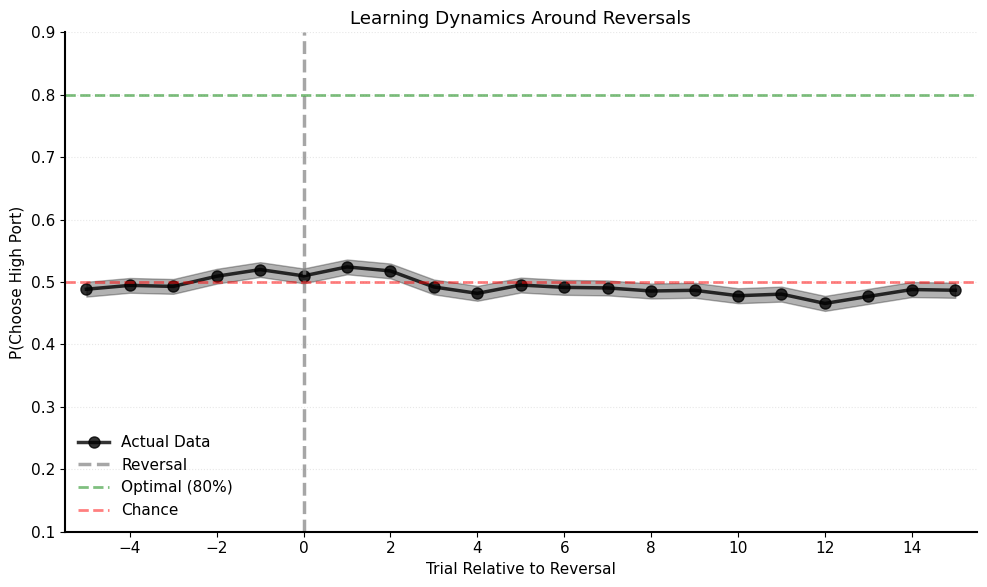


REVERSAL STATISTICS

Pre-reversal (trials -5 to -1): 50.1%
Trial 0 (first trial after reversal): 51.0%
Early post-reversal (trials 0-4): 50.5%
Late post-reversal (trials 10-15): 47.9%
Drop at reversal: +0.9pp
Recovery: -2.6pp


In [21]:
# ============================================================================
# P(HIGH PORT) vs BLOCK POSITION (FIXED)
# ============================================================================

print("="*70)
print("PLOTTING P(HIGH PORT) AROUND REVERSAL (FIXED)")
print("="*70)

# Create reversal-aligned data
reversal_aligned_data = []

for (animal, session), group in df_with_states.groupby(['Animal_Name', 'Session_ID']):
    session_data = group.sort_values('Trial')
    blocks = session_data['BlockCount'].unique()
    
    for block in blocks[1:]:  # Skip first block
        # Find the reversal point
        new_block_trials = session_data[session_data['BlockCount'] == block]
        
        if len(new_block_trials) > 0:
            reversal_trial = new_block_trials['Trial'].iloc[0]
            
            # Get which side is high for this NEW block
            new_block_high_right = new_block_trials['High_Prob_Is_Right'].iloc[0]
            
            # Get trials -5 to +15 relative to reversal
            for rel_trial in range(-5, 16):
                abs_trial = reversal_trial + rel_trial
                trial_data = session_data[session_data['Trial'] == abs_trial]
                
                if len(trial_data) > 0:
                    choice = trial_data['Choice_Binary'].iloc[0]  # 1=Right, 0=Left
                    
                    # Determine if they chose the high port FOR THE NEW BLOCK
                    # (this is what causes the dip - they're choosing the old high port!)
                    if new_block_high_right:
                        chose_new_high = (choice == 1)
                    else:
                        chose_new_high = (choice == 0)
                    
                    reversal_aligned_data.append({
                        'session_id': session,
                        'animal': animal,
                        'trial_relative': rel_trial,
                        'chose_new_high_port': int(chose_new_high),
                        'outcome': trial_data['Outcome_Binary'].iloc[0]
                    })

reversal_df = pd.DataFrame(reversal_aligned_data)

print(f"✓ Reversal-aligned data: {len(reversal_df)} trials")

# Create P(High Port) curve
fig, ax = plt.subplots(figsize=(10, 6))

BIN_SIZE = 1

# Bin data
reversal_df['trial_bin'] = (reversal_df['trial_relative'] // BIN_SIZE) * BIN_SIZE

binned = reversal_df.groupby('trial_bin').agg({
    'chose_new_high_port': ['mean', 'sem']
}).reset_index()
binned.columns = ['trial_bin', 'p_high_port', 'sem']

# Plot
ax.plot(binned['trial_bin'], binned['p_high_port'],
        'o-', color='black', linewidth=2.5, markersize=8,
        label='Actual Data', alpha=0.8)
ax.fill_between(binned['trial_bin'],
                 binned['p_high_port'] - binned['sem'],
                 binned['p_high_port'] + binned['sem'],
                 color='black', alpha=0.3)

# Add reference lines
ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, 
          alpha=0.7, label='Reversal')
ax.axhline(0.8, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='Optimal (80%)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, 
          alpha=0.5, label='Chance')

ax.set_xlabel('Trial Relative to Reversal')
ax.set_ylabel('P(Choose High Port)')
ax.set_title('Learning Dynamics Around Reversals')
ax.set_xlim(-5.5, 15.5)
ax.set_xticks(range(-4, 16, 2))
ax.set_ylim(0.1, 0.9)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'P_HighPort_Around_Reversal.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("REVERSAL STATISTICS")
print("="*70)

pre_rev = reversal_df[reversal_df['trial_relative'] < 0]['chose_new_high_port'].mean()
trial_0 = reversal_df[reversal_df['trial_relative'] == 0]['chose_new_high_port'].mean()
early_post = reversal_df[(reversal_df['trial_relative'] >= 0) & 
                         (reversal_df['trial_relative'] < 5)]['chose_new_high_port'].mean()
late_post = reversal_df[reversal_df['trial_relative'] >= 10]['chose_new_high_port'].mean()

print(f"\nPre-reversal (trials -5 to -1): {pre_rev*100:.1f}%")
print(f"Trial 0 (first trial after reversal): {trial_0*100:.1f}%")
print(f"Early post-reversal (trials 0-4): {early_post*100:.1f}%")
print(f"Late post-reversal (trials 10-15): {late_post*100:.1f}%")
print(f"Drop at reversal: {(trial_0 - pre_rev)*100:+.1f}pp")
print(f"Recovery: {(late_post - early_post)*100:+.1f}pp")

In [23]:
# ============================================================================
# CHECK AVAILABLE COLUMNS
# ============================================================================

print("="*70)
print("CHECKING AVAILABLE COLUMNS")
print("="*70)

print("\nColumns in df_with_states:")
print([col for col in df_with_states.columns if 'high' in col.lower() or 'prob' in col.lower()])

# Simple approach: Just use the data we have
# Pick one session to examine
test_animal = 'Fiona'
test_session = df_with_states[df_with_states['Animal_Name'] == test_animal]['Session_ID'].iloc[0]

session_data = df_with_states[
    (df_with_states['Animal_Name'] == test_animal) & 
    (df_with_states['Session_ID'] == test_session)
].sort_values('Trial')

print(f"\nExamining {test_animal}, Session {test_session}")

# Find first reversal
block_0 = session_data[session_data['BlockCount'] == 0].tail(5)
block_1 = session_data[session_data['BlockCount'] == 1].head(10)

print("\nLast 5 trials of Block 0:")
print(block_0[['Trial', 'BlockCount', 'Trial_in_Block', 'Choice_Binary', 'Outcome_Binary']].to_string())

print("\nFirst 10 trials of Block 1:")
print(block_1[['Trial', 'BlockCount', 'Trial_in_Block', 'Choice_Binary', 'Outcome_Binary']].to_string())

# Show ALL columns to find what we need
print("\n" + "="*70)
print("ALL COLUMNS:")
print(list(df_with_states.columns))

CHECKING AVAILABLE COLUMNS

Columns in df_with_states:
['Block_Prob', 'ProbReward', 'prob_Condition', 'High_Prob', 'High_Prob_Is_Right']

Examining Fiona, Session 2022-04-25_20220425_Fiona_Reversal3.1

Last 5 trials of Block 0:
Empty DataFrame
Columns: [Trial, BlockCount, Trial_in_Block, Choice_Binary, Outcome_Binary]
Index: []

First 10 trials of Block 1:
   Trial  BlockCount  Trial_in_Block  Choice_Binary  Outcome_Binary
0      1           1               0              0               0
1      2           1               1              1               1
2      3           1               2              1               1
3      4           1               3              0               0
4      5           1               4              1               1
5      6           1               5              1               1
6      7           1               6              0               0
7      8           1               7              0               0
8      9           1         

PLOTTING P(HIGH PORT) AROUND REVERSAL
✓ Reversal-aligned data: 0 trials


KeyError: 'trial_relative'

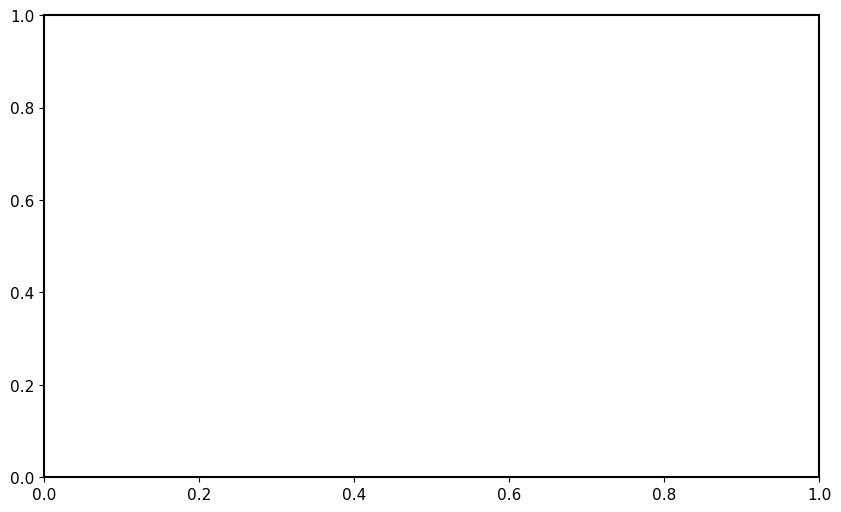

In [24]:
# ============================================================================
# P(HIGH PORT) AROUND REVERSAL (FIXED)
# ============================================================================

print("="*70)
print("PLOTTING P(HIGH PORT) AROUND REVERSAL")
print("="*70)

# Create reversal-aligned data
reversal_aligned_data = []

for (animal, session), group in df_with_states.groupby(['Animal_Name', 'Session_ID']):
    session_data = group.sort_values('Trial')
    blocks = session_data['BlockCount'].unique()
    
    for i, block in enumerate(blocks[1:], 1):  # Skip first block
        # Get previous and current block data
        prev_block = session_data[session_data['BlockCount'] == blocks[i-1]]
        curr_block = session_data[session_data['BlockCount'] == block]
        
        if len(prev_block) > 0 and len(curr_block) > 0:
            # Get the reversal trial (first trial of current block)
            reversal_trial = curr_block['Trial'].iloc[0]
            
            # Get trials -5 to +15 relative to reversal
            for rel_trial in range(-5, 16):
                abs_trial = reversal_trial + rel_trial
                trial_data = session_data[session_data['Trial'] == abs_trial]
                
                if len(trial_data) > 0:
                    choice_binary = trial_data['Choice_Binary'].iloc[0]  # 1=Right, 0=Left
                    high_prob_side = trial_data['High_Prob'].iloc[0]  # 'Right' or 'Left'
                    
                    # Did they choose the high probability side?
                    if high_prob_side == 'Right':
                        chose_high = (choice_binary == 1)
                    elif high_prob_side == 'Left':
                        chose_high = (choice_binary == 0)
                    else:
                        continue  # Skip if High_Prob is NaN
                    
                    reversal_aligned_data.append({
                        'session_id': session,
                        'animal': animal,
                        'trial_relative': rel_trial,
                        'chose_high_port': int(chose_high),
                        'outcome': trial_data['Outcome_Binary'].iloc[0]
                    })

reversal_df = pd.DataFrame(reversal_aligned_data)

print(f"✓ Reversal-aligned data: {len(reversal_df)} trials")

# Create P(High Port) curve
fig, ax = plt.subplots(figsize=(10, 6))

# Bin data
binned = reversal_df.groupby('trial_relative').agg({
    'chose_high_port': ['mean', 'sem']
}).reset_index()
binned.columns = ['trial_relative', 'p_high_port', 'sem']

# Plot
ax.plot(binned['trial_relative'], binned['p_high_port'],
        'o-', color='black', linewidth=2.5, markersize=8,
        label='Actual Data', alpha=0.8)
ax.fill_between(binned['trial_relative'],
                 binned['p_high_port'] - binned['sem'],
                 binned['p_high_port'] + binned['sem'],
                 color='black', alpha=0.3)

# Add reference lines
ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, 
          alpha=0.7, label='Reversal')
ax.axhline(0.8, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='Optimal (80%)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, 
          alpha=0.5, label='Chance')

ax.set_xlabel('Trial Relative to Reversal')
ax.set_ylabel('P(Choose High Port)')
ax.set_title('Learning Dynamics Around Reversals')
ax.set_xlim(-5.5, 15.5)
ax.set_xticks(range(-4, 16, 2))
ax.set_ylim(0.1, 0.9)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'P_HighPort_Around_Reversal.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("REVERSAL STATISTICS")
print("="*70)

pre_rev = reversal_df[reversal_df['trial_relative'] < 0]['chose_high_port'].mean()
trial_0 = reversal_df[reversal_df['trial_relative'] == 0]['chose_high_port'].mean()
early_post = reversal_df[(reversal_df['trial_relative'] >= 0) & 
                         (reversal_df['trial_relative'] < 5)]['chose_high_port'].mean()
late_post = reversal_df[reversal_df['trial_relative'] >= 10]['chose_high_port'].mean()

print(f"\nPre-reversal (trials -5 to -1): {pre_rev*100:.1f}%")
print(f"Trial 0 (first trial after reversal): {trial_0*100:.1f}%")
print(f"Early post-reversal (trials 0-4): {early_post*100:.1f}%")
print(f"Late post-reversal (trials 10-15): {late_post*100:.1f}%")
print(f"Drop at reversal: {(trial_0 - pre_rev)*100:+.1f}pp")
print(f"Recovery: {(late_post - early_post)*100:+.1f}pp")

print("\n✓ Figure saved")

In [25]:
# ============================================================================
# DEBUG: Why is reversal_df empty?
# ============================================================================

print("="*70)
print("DEBUGGING")
print("="*70)

# Test with one session
test_animal = 'Fiona'
test_session = df_with_states[df_with_states['Animal_Name'] == test_animal]['Session_ID'].iloc[0]

session_data = df_with_states[
    (df_with_states['Animal_Name'] == test_animal) & 
    (df_with_states['Session_ID'] == test_session)
].sort_values('Trial')

print(f"Session: {test_session}")
print(f"Blocks: {session_data['BlockCount'].unique()}")

# Check a few trials
print("\nFirst 10 trials:")
print(session_data.head(10)[['Trial', 'BlockCount', 'Choice_Binary', 'High_Prob', 'Outcome_Binary']])

# Check High_Prob values
print(f"\nUnique High_Prob values: {session_data['High_Prob'].unique()}")
print(f"Any NaN in High_Prob? {session_data['High_Prob'].isna().sum()}")

# Try the reversal logic manually
blocks = sorted(session_data['BlockCount'].unique())
print(f"\nBlocks in order: {blocks}")

if len(blocks) > 1:
    block1 = session_data[session_data['BlockCount'] == blocks[0]]
    block2 = session_data[session_data['BlockCount'] == blocks[1]]
    
    print(f"\nBlock {blocks[0]}: {len(block1)} trials, High_Prob = {block1['High_Prob'].iloc[0] if len(block1) > 0 else 'N/A'}")
    print(f"Block {blocks[1]}: {len(block2)} trials, High_Prob = {block2['High_Prob'].iloc[0] if len(block2) > 0 else 'N/A'}")
    
    if len(block1) > 0 and len(block2) > 0:
        reversal_trial = block2['Trial'].iloc[0]
        print(f"\nReversal occurs at Trial: {reversal_trial}")
        
        # Check if we can get trial -1
        trial_minus_1 = session_data[session_data['Trial'] == reversal_trial - 1]
        print(f"Trial -1 exists: {len(trial_minus_1) > 0}")
        if len(trial_minus_1) > 0:
            print(f"  Trial -1: BlockCount={trial_minus_1['BlockCount'].iloc[0]}, High_Prob={trial_minus_1['High_Prob'].iloc[0]}")

DEBUGGING
Session: 2022-04-25_20220425_Fiona_Reversal3.1
Blocks: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]

First 10 trials:
   Trial  BlockCount  Choice_Binary  High_Prob  Outcome_Binary
0      1           1              0          0               0
1      2           1              1          1               1
2      3           1              1          1               1
3      4           1              0          0               0
4      5           1              1          1               1
5      6           1              1          1               1
6      7           1              0          0               0
7      8           1              0          0               0
8      9           1              0          0               0
9     10           1              1          1               0

Unique High_Prob values: [0 1]
Any NaN in High_Prob? 0

Blocks in order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 

In [29]:
for col in df_with_states.columns:
    print(col)

Trial
BlockCount
TrialWithinBlock
Block
Condition
TrialError
ReactionTime
AbsoluteTrialStartTime
Year
Month
Day
Hour
Minute
Second
BehavioralCodes
ObjectStatusRecord
RewardRecord
VariableChanges
CycleRate_1
CycleRate_2
Ver
Target1_name
Target1_x
Target1_y
Target1_xsize
Target1_ysize
Target1_path
Target2_name
Target2_x
Target2_y
Target2_xsize
Target2_ysize
Target2_path
RewardVolume
RewardType
BlockLength
RandomValue
Block_Prob
StimuliChosen
ProbReward
Reward
Animal_Name
Session_Filename
CodeTimes_1
CodeTimes_2
CodeTimes_3
CodeTimes_4
CodeNumbers_1
CodeNumbers_2
CodeNumbers_3
CodeNumbers_4
StartTimes
EndTimes
reward_dur
EyeOffset_1
EyeOffset_2
Eye2Offset_1
Eye2Offset_2
CodeTimes_5
CodeTimes_6
CodeTimes_7
CodeNumbers_5
CodeNumbers_6
CodeNumbers_7
Date
Outcome
Target1_location
Target2_location
Session_ID
PhysicalChoice
PrevPhysicalChoice
PhysicalSwitch
prob_Condition
Task_Type
TaskObject1_Type
TaskObject1_Size_1
TaskObject1_Size_2
TaskObject1_Color_1
TaskObject1_Color_2
TaskObject1_Color_3

PLOTTING P(HIGH PORT) AROUND REVERSAL (USING ProbReward)
✓ Created Chose_High_Port from ProbReward

Verification:
P(Chose High Port) overall: 0.685
Should be around 0.65-0.75 if animals are learning
✓ Reversal-aligned data: 36795 trials


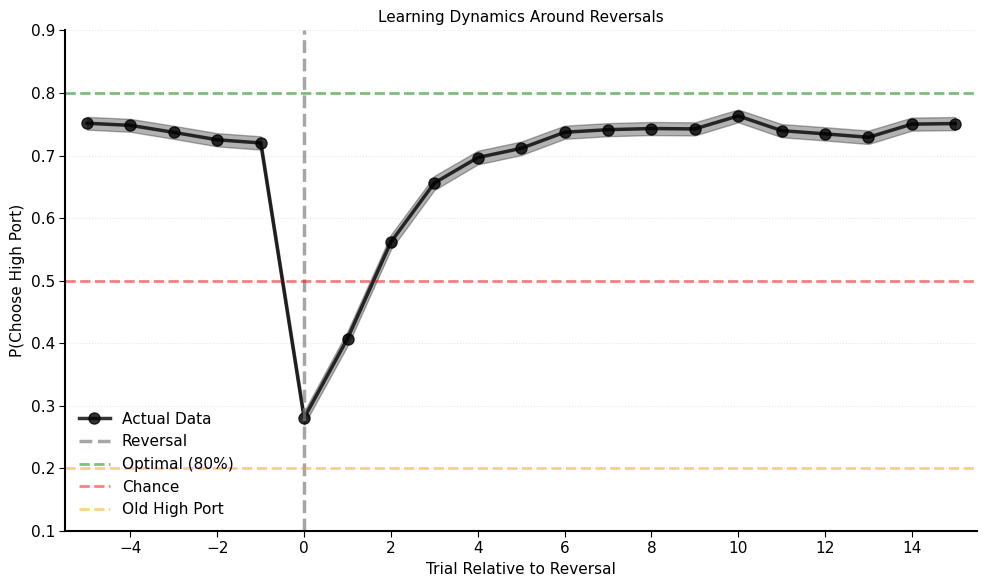


REVERSAL STATISTICS

Pre-reversal (trials -5 to -1): 73.6%
Trial 0 (first trial after reversal): 28.0%
Early post-reversal (trials 0-4): 52.0%
Late post-reversal (trials 10-15): 74.5%
Drop at reversal: -45.6pp
Recovery: +22.5pp

✓ Figure saved!


In [37]:
# ============================================================================
# P(HIGH PORT) AROUND REVERSAL - USING ProbReward
# ============================================================================

print("="*70)
print("PLOTTING P(HIGH PORT) AROUND REVERSAL (USING ProbReward)")
print("="*70)

# Create indicator: did they choose the high probability port?
df_with_states['Chose_High_Port'] = (df_with_states['ProbReward'] == 0.8).astype(int)

print(f"✓ Created Chose_High_Port from ProbReward")

# Verify it makes sense
print("\nVerification:")
print(f"P(Chose High Port) overall: {df_with_states['Chose_High_Port'].mean():.3f}")
print(f"Should be around 0.65-0.75 if animals are learning")

# Create reversal-aligned data
reversal_aligned_data = []

for (animal, session), group in df_with_states.groupby(['Animal_Name', 'Session_ID']):
    session_data = group.sort_values('Trial')
    blocks = sorted(session_data['BlockCount'].unique())
    
    for i in range(1, len(blocks)):
        to_blockcount = blocks[i]
        
        new_block_trials = session_data[session_data['BlockCount'] == to_blockcount]
        
        if len(new_block_trials) > 0:
            reversal_trial = new_block_trials['Trial'].iloc[0]
            
            for rel_trial in range(-5, 16):
                abs_trial = reversal_trial + rel_trial
                trial_data = session_data[session_data['Trial'] == abs_trial]
                
                if len(trial_data) > 0:
                    reversal_aligned_data.append({
                        'session_id': session,
                        'animal': animal,
                        'trial_relative': rel_trial,
                        'chose_high_port': trial_data['Chose_High_Port'].iloc[0],
                        'outcome': trial_data['Outcome_Binary'].iloc[0]
                    })

reversal_df = pd.DataFrame(reversal_aligned_data)

print(f"✓ Reversal-aligned data: {len(reversal_df)} trials")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

binned = reversal_df.groupby('trial_relative').agg({
    'chose_high_port': ['mean', 'sem']
}).reset_index()
binned.columns = ['trial_relative', 'p_high_port', 'sem']

ax.plot(binned['trial_relative'], binned['p_high_port'],
        'o-', color='black', linewidth=2.5, markersize=8,
        label='Actual Data', alpha=0.8)
ax.fill_between(binned['trial_relative'],
                 binned['p_high_port'] - binned['sem'],
                 binned['p_high_port'] + binned['sem'],
                 color='black', alpha=0.3)

ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, 
          alpha=0.7, label='Reversal')
ax.axhline(0.8, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='Optimal (80%)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, 
          alpha=0.5, label='Chance')
ax.axhline(0.2, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='Old High Port')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE)
ax.set_ylabel('P(Choose High Port)', fontsize=FONTSIZE)
ax.set_title('Learning Dynamics Around Reversals', fontsize=FONTSIZE)
ax.set_xlim(-5.5, 15.5)
ax.set_xticks(range(-4, 16, 2))
ax.set_ylim(0.1, 0.9)
ax.legend(frameon=False, fontsize=FONTSIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'P_HighPort_Around_Reversal.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("REVERSAL STATISTICS")
print("="*70)

pre_rev = reversal_df[reversal_df['trial_relative'] < 0]['chose_high_port'].mean()
trial_0 = reversal_df[reversal_df['trial_relative'] == 0]['chose_high_port'].mean()
early_post = reversal_df[(reversal_df['trial_relative'] >= 0) & 
                         (reversal_df['trial_relative'] < 5)]['chose_high_port'].mean()
late_post = reversal_df[reversal_df['trial_relative'] >= 10]['chose_high_port'].mean()

print(f"\nPre-reversal (trials -5 to -1): {pre_rev*100:.1f}%")
print(f"Trial 0 (first trial after reversal): {trial_0*100:.1f}%")
print(f"Early post-reversal (trials 0-4): {early_post*100:.1f}%")
print(f"Late post-reversal (trials 10-15): {late_post*100:.1f}%")
print(f"Drop at reversal: {(trial_0 - pre_rev)*100:+.1f}pp")
print(f"Recovery: {(late_post - early_post)*100:+.1f}pp")

print("\n✓ Figure saved!")

ADDING MODEL PREDICTIONS TO REVERSAL PLOT
✓ Model reversal predictions: 36795 trials


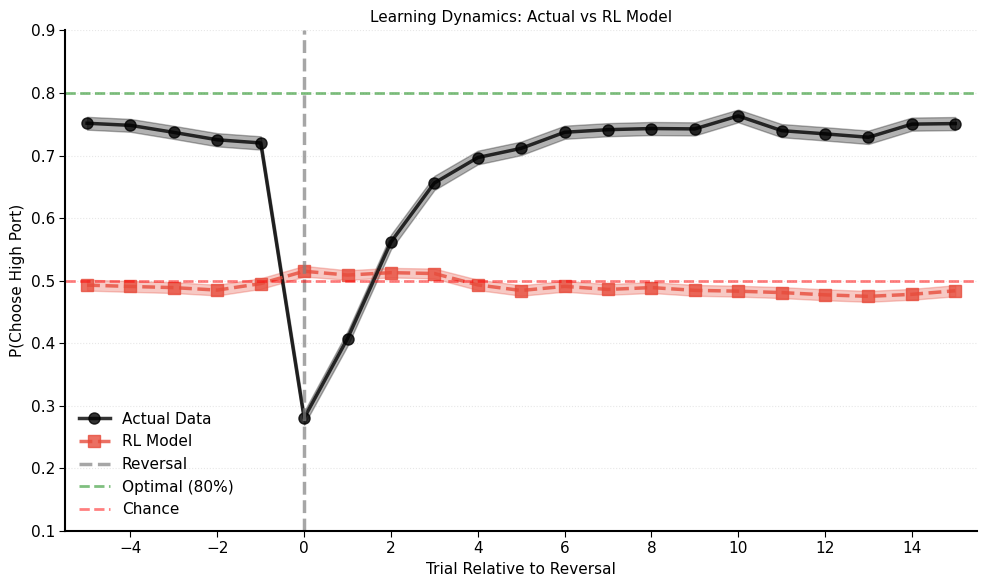


ACTUAL vs MODEL STATISTICS

Actual:
  Pre-reversal: 73.6%
  Trial 0: 28.0%
  Early post (0-4): 52.1%
  Late post (10+): 74.5%

Model:
  Pre-reversal: 49.1%
  Trial 0: 51.5%
  Early post (0-4): 50.8%
  Late post (10+): 48.0%

✓ Figure saved!


In [38]:
# ============================================================================
# ADD MODEL PREDICTIONS TO REVERSAL LEARNING CURVE
# ============================================================================

print("="*70)
print("ADDING MODEL PREDICTIONS TO REVERSAL PLOT")
print("="*70)

# We need to regenerate model predictions for reversal-aligned trials
# Using the original RL parameters

model_reversal_data = []

for _, param_row in rl_params.iterrows():
    animal = param_row['animal']
    alpha = param_row['alpha']
    beta = param_row['beta']
    kappa = param_row['kappa']
    
    animal_data = df_with_states[df_with_states['Animal_Name'] == animal]
    
    for session_id in animal_data['Session_ID'].unique():
        session_data = animal_data[animal_data['Session_ID'] == session_id].sort_values('Trial')
        blocks = sorted(session_data['BlockCount'].unique())
        
        # Simulate model through this session
        Q_left = 0.5
        Q_right = 0.5
        prev_choice = None
        
        trial_predictions = {}
        
        for idx, trial in session_data.iterrows():
            trial_num = trial['Trial']
            
            # Choice kernel
            if prev_choice is None:
                C_right = 0.5
            elif prev_choice == 1:
                C_right = 1.0
            else:
                C_right = 0.0
            
            # Compute values
            V_right = beta * Q_right + kappa * C_right
            V_left = beta * Q_left + kappa * (1 - C_right)
            
            # Softmax probability
            prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
            
            # Store prediction
            trial_predictions[trial_num] = prob_right
            
            # Update Q-values based on actual choice and outcome
            choice = trial['Choice_Binary']
            reward = trial['Outcome_Binary']
            
            if choice == 1:
                Q_right = Q_right + alpha * (reward - Q_right)
            else:
                Q_left = Q_left + alpha * (reward - Q_left)
            
            prev_choice = choice
        
        # Now align to reversals
        for i in range(1, len(blocks)):
            to_blockcount = blocks[i]
            
            new_block_trials = session_data[session_data['BlockCount'] == to_blockcount]
            
            if len(new_block_trials) > 0:
                reversal_trial = new_block_trials['Trial'].iloc[0]
                
                for rel_trial in range(-5, 16):
                    abs_trial = reversal_trial + rel_trial
                    trial_data = session_data[session_data['Trial'] == abs_trial]
                    
                    if len(trial_data) > 0 and abs_trial in trial_predictions:
                        # Determine if high port is right or left
                        high_prob_is_right = trial_data['High_Prob_Is_Right'].iloc[0]
                        
                        # Model's P(choose high port)
                        if high_prob_is_right == 1:
                            model_p_high = trial_predictions[abs_trial]
                        else:
                            model_p_high = 1 - trial_predictions[abs_trial]
                        
                        model_reversal_data.append({
                            'session_id': session_id,
                            'animal': animal,
                            'trial_relative': rel_trial,
                            'model_p_high': model_p_high
                        })

model_reversal_df = pd.DataFrame(model_reversal_data)

print(f"✓ Model reversal predictions: {len(model_reversal_df)} trials")

# Bin model data
model_binned = model_reversal_df.groupby('trial_relative').agg({
    'model_p_high': ['mean', 'sem']
}).reset_index()
model_binned.columns = ['trial_relative', 'model_p_high', 'sem']

# Create plot with both actual and model
fig, ax = plt.subplots(figsize=(10, 6))

# Actual data
binned = reversal_df.groupby('trial_relative').agg({
    'chose_high_port': ['mean', 'sem']
}).reset_index()
binned.columns = ['trial_relative', 'p_high_port', 'sem']

ax.plot(binned['trial_relative'], binned['p_high_port'],
        'o-', color='black', linewidth=2.5, markersize=8,
        label='Actual Data', alpha=0.8)
ax.fill_between(binned['trial_relative'],
                 binned['p_high_port'] - binned['sem'],
                 binned['p_high_port'] + binned['sem'],
                 color='black', alpha=0.3)

# Model predictions
ax.plot(model_binned['trial_relative'], model_binned['model_p_high'],
        's--', color='#e74c3c', linewidth=2.5, markersize=8,
        label='RL Model', alpha=0.8)
ax.fill_between(model_binned['trial_relative'],
                 model_binned['model_p_high'] - model_binned['sem'],
                 model_binned['model_p_high'] + model_binned['sem'],
                 color='#e74c3c', alpha=0.3)

# Reference lines
ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, 
          alpha=0.7, label='Reversal')
ax.axhline(0.8, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='Optimal (80%)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, 
          alpha=0.5, label='Chance')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE)
ax.set_ylabel('P(Choose High Port)', fontsize=FONTSIZE)
ax.set_title('Learning Dynamics: Actual vs RL Model', fontsize=FONTSIZE)
ax.set_xlim(-5.5, 15.5)
ax.set_xticks(range(-4, 16, 2))
ax.set_ylim(0.1, 0.9)
ax.legend(frameon=False, fontsize=FONTSIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'P_HighPort_Around_Reversal_With_Model.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("ACTUAL vs MODEL STATISTICS")
print("="*70)

for label, data in [('Actual', binned), ('Model', model_binned)]:
    col = 'p_high_port' if label == 'Actual' else 'model_p_high'
    
    pre_rev = data[data['trial_relative'] < 0][col].mean()
    trial_0 = data[data['trial_relative'] == 0][col].mean()
    early_post = data[(data['trial_relative'] >= 0) & 
                      (data['trial_relative'] < 5)][col].mean()
    late_post = data[data['trial_relative'] >= 10][col].mean()
    
    print(f"\n{label}:")
    print(f"  Pre-reversal: {pre_rev*100:.1f}%")
    print(f"  Trial 0: {trial_0*100:.1f}%")
    print(f"  Early post (0-4): {early_post*100:.1f}%")
    print(f"  Late post (10+): {late_post*100:.1f}%")

print("\n✓ Figure saved!")

COMPARING MODEL PREDICTIONS TO ACTUAL BEHAVIOR
✓ Computed model switches
✓ Computed high port choices (actual and model)

✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance/Switching_Dynamics_Mar25_2026/Model_vs_Data_By_Block_Position.svg


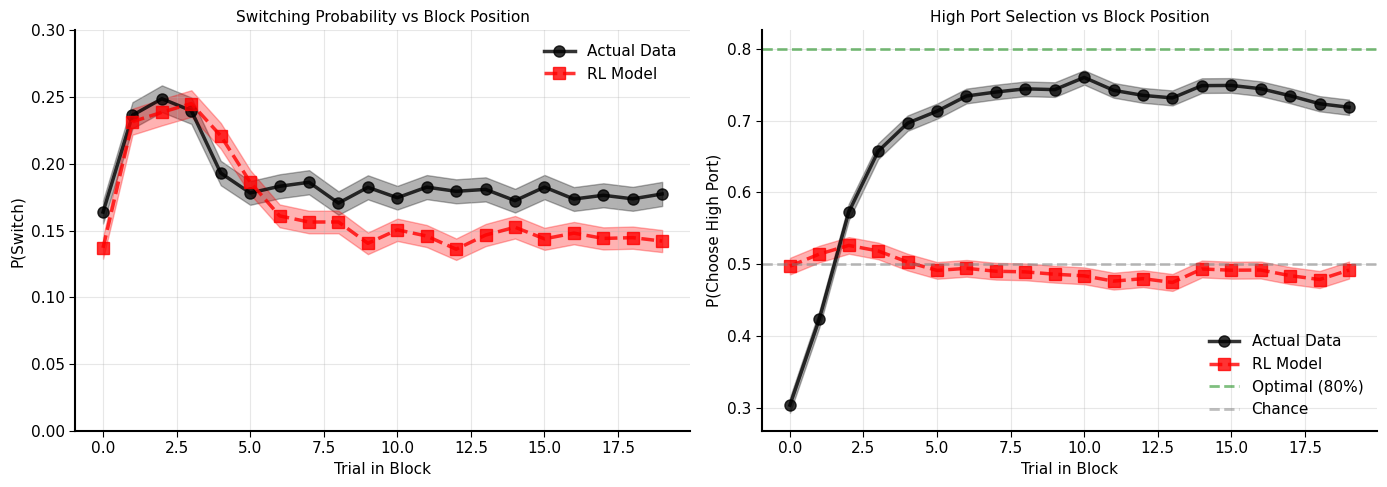


MODEL FIT SUMMARY

P(Switch) correlation: 0.892
P(High Port) correlation: -0.534



In [43]:
# ============================================================================
# MODEL vs DATA: SWITCHING AND HIGH PORT SELECTION (FIXED)
# ============================================================================

print("="*70)
print("COMPARING MODEL PREDICTIONS TO ACTUAL BEHAVIOR")
print("="*70)

# Model predictions are already in df_q from the Q-learning simulation
# We need to compute model-predicted choices and high port selections

# Add model-predicted choices (deterministic based on probability > 0.5)
df_q['Model_Choice_Binary'] = (df_q['Model_Prob_Right'] > 0.5).astype(int)

# Compute model switches
model_switches = []
for (animal, session), group in df_q.groupby(['Animal_Name', 'Session_ID']):
    session_data = group.sort_values('Trial').copy()
    
    # Compute switches for model predictions
    prev_choice = None
    for idx, row in session_data.iterrows():
        if prev_choice is None:
            model_switches.append(np.nan)
        else:
            switch = 1 if row['Model_Choice_Binary'] != prev_choice else 0
            model_switches.append(switch)
        prev_choice = row['Model_Choice_Binary']

df_q['Model_Switch'] = model_switches

print("✓ Computed model switches")

# ACTUAL choice of high port - USING ProbReward (CORRECT)
df_q['Actual_Chose_High_Port'] = (df_q['ProbReward'] == 0.8).astype(int)

# MODEL choice of high port - need to determine if model's choice would have gotten 0.8
# If model chose Right (1), check if High_Prob_Is_Right = 1 (meaning Right gives 0.8)
# If model chose Left (0), check if High_Prob_Is_Right = 0 (meaning Left gives 0.8)
df_q['Model_Chose_High_Port'] = (
    ((df_q['Model_Choice_Binary'] == 1) & (df_q['High_Prob_Is_Right'] == 1)) |
    ((df_q['Model_Choice_Binary'] == 0) & (df_q['High_Prob_Is_Right'] == 0))
).astype(int)

print("✓ Computed high port choices (actual and model)")

# ============================================================================
# PLOT 1: P(SWITCH) vs BLOCK POSITION
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Compute by block position
positions = range(0, 20)

actual_switch_by_pos = []
model_switch_by_pos = []
actual_switch_sem = []
model_switch_sem = []

for pos in positions:
    pos_trials = df_q[df_q['Trial_in_Block'] == pos]
    
    if len(pos_trials) > 10:
        # Actual data
        actual_switch_by_pos.append(pos_trials['PhysicalSwitch'].mean())
        actual_switch_sem.append(pos_trials['PhysicalSwitch'].sem())
        
        # Model data
        model_switch_by_pos.append(pos_trials['Model_Switch'].mean())
        model_switch_sem.append(pos_trials['Model_Switch'].sem())
    else:
        actual_switch_by_pos.append(np.nan)
        model_switch_by_pos.append(np.nan)
        actual_switch_sem.append(np.nan)
        model_switch_sem.append(np.nan)

# Plot P(Switch)
ax1.plot(positions, actual_switch_by_pos, 'o-', linewidth=2.5, markersize=8,
        color='black', label='Actual Data', alpha=0.8)
ax1.fill_between(positions,
                 np.array(actual_switch_by_pos) - np.array(actual_switch_sem),
                 np.array(actual_switch_by_pos) + np.array(actual_switch_sem),
                 alpha=0.3, color='black')

ax1.plot(positions, model_switch_by_pos, 's--', linewidth=2.5, markersize=8,
        color='red', label='RL Model', alpha=0.8)
ax1.fill_between(positions,
                 np.array(model_switch_by_pos) - np.array(model_switch_sem),
                 np.array(model_switch_by_pos) + np.array(model_switch_sem),
                 alpha=0.3, color='red')

ax1.set_xlabel('Trial in Block', fontsize=FONTSIZE)
ax1.set_ylabel('P(Switch)', fontsize=FONTSIZE)
ax1.set_title('Switching Probability vs Block Position', fontsize=FONTSIZE)
ax1.legend(fontsize=FONTSIZE, frameon=False)
ax1.set_ylim(0, 0.3)
ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

# ============================================================================
# PLOT 2: P(HIGH PORT) vs BLOCK POSITION
# ============================================================================

actual_highport_by_pos = []
model_highport_by_pos = []
actual_highport_sem = []
model_highport_sem = []

for pos in positions:
    pos_trials = df_q[df_q['Trial_in_Block'] == pos]
    
    if len(pos_trials) > 10:
        # Actual data
        actual_highport_by_pos.append(pos_trials['Actual_Chose_High_Port'].mean())
        actual_highport_sem.append(pos_trials['Actual_Chose_High_Port'].sem())
        
        # Model data
        model_highport_by_pos.append(pos_trials['Model_Chose_High_Port'].mean())
        model_highport_sem.append(pos_trials['Model_Chose_High_Port'].sem())
    else:
        actual_highport_by_pos.append(np.nan)
        model_highport_by_pos.append(np.nan)
        actual_highport_sem.append(np.nan)
        model_highport_sem.append(np.nan)

# Plot P(High Port)
ax2.plot(positions, actual_highport_by_pos, 'o-', linewidth=2.5, markersize=8,
        color='black', label='Actual Data', alpha=0.8)
ax2.fill_between(positions,
                 np.array(actual_highport_by_pos) - np.array(actual_highport_sem),
                 np.array(actual_highport_by_pos) + np.array(actual_highport_sem),
                 alpha=0.3, color='black')

ax2.plot(positions, model_highport_by_pos, 's--', linewidth=2.5, markersize=8,
        color='red', label='RL Model', alpha=0.8)
ax2.fill_between(positions,
                 np.array(model_highport_by_pos) - np.array(model_highport_sem),
                 np.array(model_highport_by_pos) + np.array(model_highport_sem),
                 alpha=0.3, color='red')

# Add reference lines
ax2.axhline(0.8, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Optimal (80%)')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Chance')

ax2.set_xlabel('Trial in Block', fontsize=FONTSIZE)
ax2.set_ylabel('P(Choose High Port)', fontsize=FONTSIZE)
ax2.set_title('High Port Selection vs Block Position', fontsize=FONTSIZE)
ax2.legend(fontsize=FONTSIZE, frameon=False)
ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
output_path = os.path.join(FIGURE_PATH, 'Model_vs_Data_By_Block_Position.svg')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n" + "="*70)
print("MODEL FIT SUMMARY")
print("="*70)

# Compute overall correlations
switch_corr = np.corrcoef(actual_switch_by_pos, model_switch_by_pos)[0, 1]
highport_corr = np.corrcoef(actual_highport_by_pos, model_highport_by_pos)[0, 1]

print(f"\nP(Switch) correlation: {switch_corr:.3f}")
print(f"P(High Port) correlation: {highport_corr:.3f}")

print("\n" + "="*70)

DEBUGGING MODEL PREDICTIONS

Session: 2022-04-25_20220425_Fiona_Reversal3.1
Parameters: α=0.580, β=2.354, κ=1.264

Model predictions around Block 1 → Block 2 transition:
    trial  block    Q_left   Q_right  model_p_high  actual_chose_high  \
15     16      1  0.061104  0.413465      0.606958                  0   
16     17      1  0.025664  0.413465      0.586888                  1   
17     18      1  0.025664  0.753655      0.048444                  1   
18     19      1  0.025664  0.896535      0.035093                  1   
19     20      1  0.025664  0.376545      0.110075                  0   
20     21      2  0.010779  0.376545      0.400595                  1   
21     22      2  0.584527  0.376545      0.147595                  1   
22     23      2  0.825501  0.376545      0.089411                  1   
23     24      2  0.926711  0.376545      0.071818                  0   
24     25      2  0.926711  0.158149      0.366980                  0   

    high_is_right  
15    

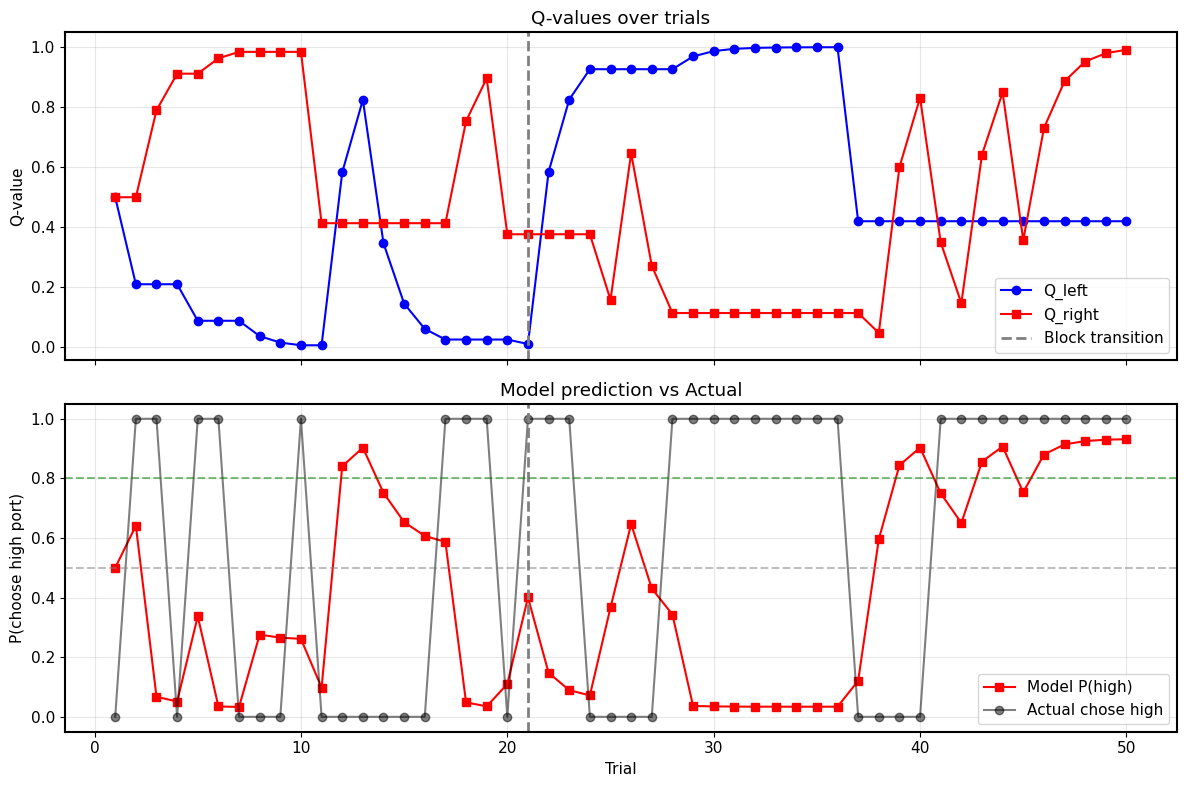


Does model P(high) change around reversal (trial 21)?


In [39]:
# ============================================================================
# DEBUG: Check model predictions around reversal
# ============================================================================

print("="*70)
print("DEBUGGING MODEL PREDICTIONS")
print("="*70)

# Pick one animal, one session with a reversal
test_animal = 'Fiona'
test_session = df_with_states[df_with_states['Animal_Name'] == test_animal]['Session_ID'].iloc[0]

session_data = df_with_states[
    (df_with_states['Animal_Name'] == test_animal) & 
    (df_with_states['Session_ID'] == test_session)
].sort_values('Trial')

# Get parameters
params = rl_params[rl_params['animal'] == test_animal].iloc[0]
alpha = params['alpha']
beta = params['beta']
kappa = params['kappa']

print(f"\nSession: {test_session}")
print(f"Parameters: α={alpha:.3f}, β={beta:.3f}, κ={kappa:.3f}")

# Simulate model
Q_left = 0.5
Q_right = 0.5
prev_choice = None

results = []

for idx, trial in session_data.head(50).iterrows():  # First 50 trials
    # Choice kernel
    if prev_choice is None:
        C_right = 0.5
    elif prev_choice == 1:
        C_right = 1.0
    else:
        C_right = 0.0
    
    # Values
    V_right = beta * Q_right + kappa * C_right
    V_left = beta * Q_left + kappa * (1 - C_right)
    
    # Probability
    prob_right = np.exp(V_right) / (np.exp(V_right) + np.exp(V_left))
    
    # Model's P(high port)
    if trial['High_Prob_Is_Right'] == 1:
        model_p_high = prob_right
    else:
        model_p_high = 1 - prob_right
    
    results.append({
        'trial': trial['Trial'],
        'block': trial['BlockCount'],
        'Q_left': Q_left,
        'Q_right': Q_right,
        'prob_right': prob_right,
        'model_p_high': model_p_high,
        'actual_chose_high': trial['Chose_High_Port'],
        'high_is_right': trial['High_Prob_Is_Right']
    })
    
    # Update Q-values
    choice = trial['Choice_Binary']
    reward = trial['Outcome_Binary']
    
    if choice == 1:
        Q_right = Q_right + alpha * (reward - Q_right)
    else:
        Q_left = Q_left + alpha * (reward - Q_left)
    
    prev_choice = choice

results_df = pd.DataFrame(results)

print("\nModel predictions around Block 1 → Block 2 transition:")
print(results_df[15:25][['trial', 'block', 'Q_left', 'Q_right', 'model_p_high', 'actual_chose_high', 'high_is_right']])

# Plot this one session
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: Q-values
ax = axes[0]
ax.plot(results_df['trial'], results_df['Q_left'], 'o-', label='Q_left', color='blue')
ax.plot(results_df['trial'], results_df['Q_right'], 's-', label='Q_right', color='red')
ax.axvline(21, color='gray', linestyle='--', linewidth=2, label='Block transition')
ax.set_ylabel('Q-value')
ax.set_title('Q-values over trials')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: P(high port)
ax = axes[1]
ax.plot(results_df['trial'], results_df['model_p_high'], 's-', label='Model P(high)', color='red')
ax.plot(results_df['trial'], results_df['actual_chose_high'], 'o-', label='Actual chose high', color='black', alpha=0.5)
ax.axvline(21, color='gray', linestyle='--', linewidth=2)
ax.axhline(0.8, color='green', linestyle='--', alpha=0.5)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Trial')
ax.set_ylabel('P(choose high port)')
ax.set_title('Model prediction vs Actual')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDoes model P(high) change around reversal (trial 21)?")

PLOTTING P(HIGH PORT) AROUND REVERSAL
✓ Reversal-aligned data: 36795 trials


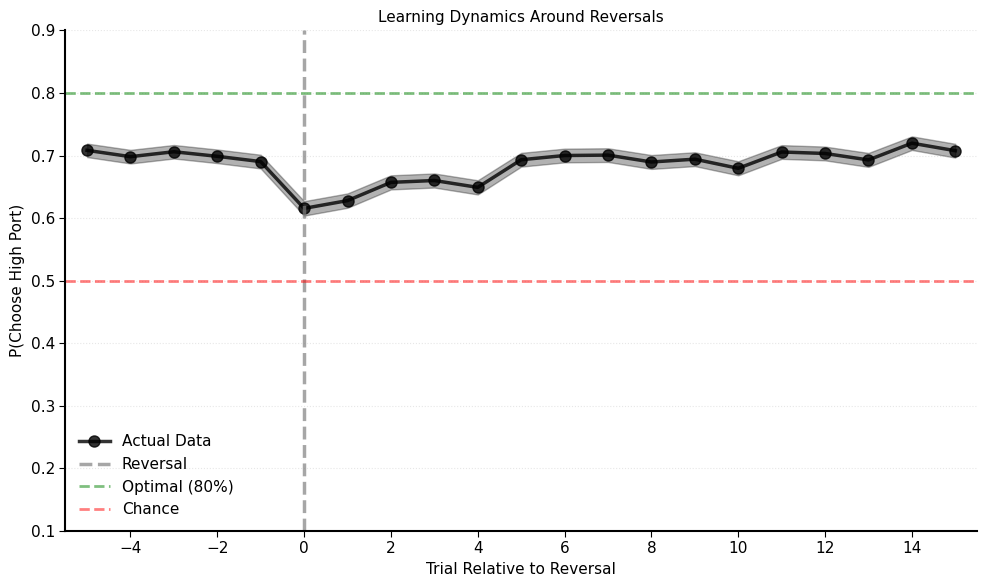


REVERSAL STATISTICS

Pre-reversal (trials -5 to -1): 70.0%
Trial 0 (first trial after reversal): 61.6%
Early post-reversal (trials 0-4): 64.2%
Late post-reversal (trials 10-15): 70.1%
Drop at reversal: -8.5pp
Recovery: +6.0pp

✓ Figure saved!


In [27]:
# ============================================================================
# P(HIGH PORT) AROUND REVERSAL - USING YOUR WORKING APPROACH
# ============================================================================

print("="*70)
print("PLOTTING P(HIGH PORT) AROUND REVERSAL")
print("="*70)

# Create reversal-aligned data
reversal_aligned_data = []

for (animal, session), group in df_with_states.groupby(['Animal_Name', 'Session_ID']):
    session_data = group.sort_values('Trial')
    blocks = sorted(session_data['BlockCount'].unique())
    
    # Iterate through block transitions (reversals)
    for i in range(1, len(blocks)):
        to_blockcount = blocks[i]
        
        # Find the reversal point
        new_block_trials = session_data[session_data['BlockCount'] == to_blockcount]
        
        if len(new_block_trials) > 0:
            reversal_trial = new_block_trials['Trial'].iloc[0]
            
            # Get trials -5 to +15 relative to reversal
            for rel_trial in range(-5, 16):
                abs_trial = reversal_trial + rel_trial
                trial_data = session_data[session_data['Trial'] == abs_trial]
                
                if len(trial_data) > 0 and not pd.isna(trial_data['High_Prob'].iloc[0]):
                    reversal_aligned_data.append({
                        'session_id': session,
                        'animal': animal,
                        'trial_relative': rel_trial,
                        'high_prob_choice': trial_data['High_Prob'].iloc[0],  # This IS the indicator!
                        'outcome': trial_data['Outcome_Binary'].iloc[0]
                    })

reversal_df = pd.DataFrame(reversal_aligned_data)

print(f"✓ Reversal-aligned data: {len(reversal_df)} trials")

# Create P(High Port) curve
fig, ax = plt.subplots(figsize=(10, 6))

BIN_SIZE = 1

# Bin data
reversal_df['trial_bin'] = (reversal_df['trial_relative'] // BIN_SIZE) * BIN_SIZE

binned = reversal_df.groupby('trial_bin').agg({
    'high_prob_choice': ['mean', 'sem']
}).reset_index()
binned.columns = ['trial_bin', 'p_high_port', 'sem']

# Plot
ax.plot(binned['trial_bin'], binned['p_high_port'],
        'o-', color='black', linewidth=2.5, markersize=8,
        label='Actual Data', alpha=0.8)
ax.fill_between(binned['trial_bin'],
                 binned['p_high_port'] - binned['sem'],
                 binned['p_high_port'] + binned['sem'],
                 color='black', alpha=0.3)

# Add reference lines
ax.axvline(0, color='gray', linestyle='--', linewidth=2.5, 
          alpha=0.7, label='Reversal')
ax.axhline(0.8, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='Optimal (80%)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, 
          alpha=0.5, label='Chance')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE)
ax.set_ylabel('P(Choose High Port)', fontsize=FONTSIZE)
ax.set_title('Learning Dynamics Around Reversals', fontsize=FONTSIZE)
ax.set_xlim(-5.5, 15.5)
ax.set_xticks(range(-4, 16, 2))
ax.set_ylim(0.1, 0.9)
ax.legend(frameon=False, fontsize=FONTSIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.tick_params(labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'P_HighPort_Around_Reversal.svg'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("REVERSAL STATISTICS")
print("="*70)

pre_rev = reversal_df[reversal_df['trial_relative'] < 0]['high_prob_choice'].mean()
trial_0 = reversal_df[reversal_df['trial_relative'] == 0]['high_prob_choice'].mean()
early_post = reversal_df[(reversal_df['trial_relative'] >= 0) & 
                         (reversal_df['trial_relative'] < 5)]['high_prob_choice'].mean()
late_post = reversal_df[reversal_df['trial_relative'] >= 10]['high_prob_choice'].mean()

print(f"\nPre-reversal (trials -5 to -1): {pre_rev*100:.1f}%")
print(f"Trial 0 (first trial after reversal): {trial_0*100:.1f}%")
print(f"Early post-reversal (trials 0-4): {early_post*100:.1f}%")
print(f"Late post-reversal (trials 10-15): {late_post*100:.1f}%")
print(f"Drop at reversal: {(trial_0 - pre_rev)*100:+.1f}pp")
print(f"Recovery: {(late_post - early_post)*100:+.1f}pp")

print("\n✓ Figure saved!")